# Import libraries

In [1]:
import gc
import os
from copy import deepcopy
import warnings
import bisect
from collections import defaultdict

import psutil
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from kaggle.api.kaggle_api_extended import KaggleApi
from feature_engine.variable_handling import (
    find_categorical_variables,
    find_numerical_variables,
)

from kvbiii_plots.eda.categorical_plots import CategoricalPlots
from kvbiii_plots.eda.continuous_plots import ContinuousPlots
from kvbiii_plots.evaluation.regression_plots import RegressionPlots
from kvbiii_plots.ml.other_plots import OtherPlots
from kvbiii_plots.ml.optuna_plots import OptunaPlots
from kvbiii_plots.evaluation.shap_plots import SHAPPlots

from kvbiii_ml.data_processing.eda.data_analysis import DataAnalyzer
from kvbiii_ml.data_processing.eda.data_transformation import DataTransformer
from kvbiii_ml.data_processing.feature_engineering.case_normalizer import CaseNormalizer
from kvbiii_ml.data_processing.feature_engineering.categorical_aligner import CategoricalAligner
from kvbiii_ml.data_processing.feature_engineering.numerical_downcaster import NumericalDowncaster
from kvbiii_ml.data_processing.feature_engineering.digits_encoding import DigitsEncodingFeatureGenerator
from kvbiii_ml.data_processing.preprocessing.discretisation.kbins_discretiser import KBinsDiscretiserWithOriginal
from kvbiii_ml.data_processing.preprocessing.categorical_encoding.count_frequency_encoder import CountFrequencyEncoderWithOriginal
from kvbiii_ml.data_processing.preprocessing.categorical_encoding.target_encoder import TargetEncoderWithOriginal
from kvbiii_ml.data_processing.preprocessing.pipeline_dependency import build_restricted_pipeline

from kvbiii_ml.modeling.training.cross_validation import CrossValidationTrainer
from kvbiii_ml.modeling.training.ensemble_model import EnsembleModel
from kvbiii_ml.modeling.optimization.ensemble_weights_tuner import EnsembleWeightTunerCV
from kvbiii_ml.modeling.optimization.hyperparameter_tuning import RandomSearchCV

from kvbiii_ml.evaluation.generate_reports import regression_results
from kvbiii_ml.evaluation.shap_values import compute_shap_values
from kvbiii_ml.evaluation.metrics import METRICS

warnings.filterwarnings("ignore", category=UserWarning, message="Could not infer format")

data_analyzer = DataAnalyzer()
data_transformer = DataTransformer()
categorical_plots = CategoricalPlots()
continuous_plots = ContinuousPlots()
regression_plots = RegressionPlots()
other_plots = OtherPlots()
optuna_plots = OptunaPlots()
shap_plots = SHAPPlots()

SEED = 17
PROBLEM_TYPE = "regression"
METRIC_NAME = "RMSE"
CV = KFold(n_splits=5, shuffle=True, random_state=SEED)
N_TRIALS = 100
SELECTED_FEATURES = ['1STFLRSF', '1STFLRSF_PREPROCESS_DIGIT_3_PREPROCESS_TARGET_ENC', '1STFLRSF_PREPROCESS_KBINS_500', '2NDFLRSF_PREPROCESS_DIGIT_1', 'BASEMENT_TO_LIVING_AREA_RATIO', 'BEDROOMABVGR_PREPROCESS_CNT_FREQ', 'BEDROOM_TO_ROOM_RATIO', 'BEDROOM_TO_ROOM_RATIO_PREPROCESS_DIGIT_N3_PREPROCESS_CNT_FREQ', 'BSMTEXPOSURE', 'BSMTEXPOSURE_ORDINAL', 'BSMTEXPOSURE_PREPROCESS_CNT_FREQ', 'BSMTEXPOSURE_PREPROCESS_TARGET_ENC', 'BSMTFINSF1', 'BSMTFINSF1_PREPROCESS_DIGIT_0', 'BSMTFINSF1_PREPROCESS_DIGIT_2', 'BSMTFINSF1_PREPROCESS_KBINS_500', 'BSMTFINTYPE1', 'BSMTFINTYPE1_ORDINAL', 'BSMTUNFSF', 'BSMTUNFSF_PREPROCESS_DIGIT_3_PREPROCESS_TARGET_ENC', 'BSMTUNFSF_PREPROCESS_KBINS_500', 'CENTRALAIR', 'CENTRALAIR_PREPROCESS_TARGET_ENC', 'CONDITION1', 'CONDITION1_PREPROCESS_CNT_FREQ', 'CONDITION1_PREPROCESS_TARGET_ENC', 'EXTERIOR1ST', 'EXTERIOR2ND', 'FIREPLACEQU_ORDINAL', 'FIREPLACEQU_PREPROCESS_TARGET_ENC', 'FIREPLACES_PREPROCESS_TARGET_ENC', 'FUNCTIONAL', 'FUNCTIONAL_ORDINAL', 'GARAGEAREA', 'GARAGEAREA_PREPROCESS_DIGIT_1', 'GARAGEAREA_PREPROCESS_DIGIT_2', 'GARAGEAREA_PREPROCESS_KBINS_100', 'GARAGECARS', 'GARAGECARS_PREPROCESS_CNT_FREQ', 'GARAGECARS_PREPROCESS_TARGET_ENC', 'GARAGECOND_ORDINAL', 'GARAGECOND_PREPROCESS_TARGET_ENC', 'GARAGEFINISH', 'GARAGEFINISH_ORDINAL', 'GARAGETYPE_PREPROCESS_CNT_FREQ', 'GARAGEYRBLT', 'GARAGEYRBLT_PREPROCESS_DIGIT_1', 'GARAGE_AGE_AT_SALE_YEARS', 'GARAGE_AGE_AT_SALE_YEARS_PREPROCESS_DIGIT_0', 'GARAGE_AREA_PER_CAR_SQFT', 'GARAGE_AREA_PER_CAR_SQFT_PREPROCESS_DIGIT_1', 'GRLIVAREA', 'GRLIVAREA_PREPROCESS_KBINS_500', 'HOUSE_AGE_AT_SALE_YEARS', 'HOUSE_AGE_AT_SALE_YEARS_PREPROCESS_DIGIT_1', 'KITCHENQUAL', 'KITCHENQUAL_ORDINAL', 'KITCHENQUAL_PREPROCESS_TARGET_ENC', 'LIVING_AREA_PER_ROOM_SQFT_PREPROCESS_DIGIT_0', 'LIVING_AREA_PER_ROOM_SQFT_PREPROCESS_DIGIT_1', 'LIVING_AREA_PER_ROOM_SQFT_PREPROCESS_KBINS_100', 'LIVING_AREA_PER_ROOM_SQFT_PREPROCESS_KBINS_500', 'LOTAREA', 'LOTAREA_PREPROCESS_DIGIT_1', 'LOTAREA_PREPROCESS_KBINS_100', 'LOTAREA_PREPROCESS_KBINS_500', 'LOTCONFIG', 'LOTCONFIG_PREPROCESS_TARGET_ENC', 'LOTFRONTAGE', 'LOT_DEPTH_APPROX_FT_PREPROCESS_DIGIT_0', 'MOSOLD_PREPROCESS_DIGIT_0', 'MSSUBCLASS_PREPROCESS_DIGIT_1_PREPROCESS_TARGET_ENC', 'MSZONING', 'MSZONING_PREPROCESS_CNT_FREQ', 'MSZONING_PREPROCESS_TARGET_ENC', 'NEIGHBORHOOD', 'NEIGHBORHOOD_PREPROCESS_TARGET_ENC', 'OPENPORCHSF', 'OPENPORCHSF_PREPROCESS_DIGIT_1', 'OVERALLCOND', 'OVERALLCOND_PREPROCESS_CNT_FREQ', 'OVERALLCOND_PREPROCESS_TARGET_ENC', 'OVERALLQUAL_HOUSE_AGE_INTERACTION', 'OVERALLQUAL_HOUSE_AGE_INTERACTION_PREPROCESS_DIGIT_1', 'OVERALLQUAL_LIVING_AREA_INTERACTION', 'OVERALLQUAL_LIVING_AREA_INTERACTION_PREPROCESS_DIGIT_3', 'OVERALLQUAL_LIVING_AREA_INTERACTION_PREPROCESS_KBINS_100', 'OVERALLQUAL_LIVING_AREA_INTERACTION_PREPROCESS_KBINS_500', 'OVERALLQUAL_PREPROCESS_DIGIT_0', 'OVERALLQUAL_TOTAL_LIVING_AREA_INTERACTION', 'OVERALLQUAL_TOTAL_LIVING_AREA_INTERACTION_PREPROCESS_DIGIT_3', 'OVERALLQUAL_TOTAL_LIVING_AREA_INTERACTION_PREPROCESS_DIGIT_4', 'OVERALLQUAL_TOTAL_LIVING_AREA_INTERACTION_PREPROCESS_DIGIT_4_PREPROCESS_CNT_FREQ', 'OVERALLQUAL_TOTAL_LIVING_AREA_INTERACTION_PREPROCESS_KBINS_10', 'OVERALLQUAL_TOTAL_LIVING_AREA_INTERACTION_PREPROCESS_KBINS_100', 'OVERALLQUAL_TOTAL_LIVING_AREA_INTERACTION_PREPROCESS_KBINS_500', 'PAVEDDRIVE', 'QUALITY_RATINGS_COMPOSITE_SCORE', 'QUALITY_RATINGS_COMPOSITE_SCORE_PREPROCESS_KBINS_10', 'SALECONDITION', 'SALECONDITION_PREPROCESS_CNT_FREQ', 'SALECONDITION_PREPROCESS_TARGET_ENC', 'SALETYPE_PREPROCESS_TARGET_ENC', 'TOTAL_BATHROOMS', 'TOTAL_BATHROOMS_PREPROCESS_KBINS_10', 'TOTAL_LIVING_AREA_SQFT', 'TOTAL_LIVING_AREA_SQFT_LOG1P', 'TOTAL_LIVING_AREA_SQFT_PREPROCESS_KBINS_100', 'TOTAL_LIVING_AREA_SQFT_PREPROCESS_KBINS_500', 'TOTAL_PORCH_AREA_SQFT', 'TOTAL_PORCH_AREA_SQFT_PREPROCESS_KBINS_100', 'TOTRMSABVGRD_PREPROCESS_DIGIT_1_PREPROCESS_TARGET_ENC', 'YEARBUILT', 'YEARREMODADD', 'YEARS_SINCE_REMODEL_AT_SALE', 'YRSOLD_PREPROCESS_CNT_FREQ']

cross_validation_trainer = CrossValidationTrainer(metric_name=METRIC_NAME, problem_type=PROBLEM_TYPE, cv=CV, verbose=False)

# Load dataset

In [2]:
def load_data(folder_name: str = "data") -> tuple[pd.DataFrame, pd.DataFrame]:
    """Loads the train and test datasets from the specified folder."""
    train_csv = os.path.join(folder_name, "train.csv")
    test_csv = os.path.join(folder_name, "test.csv")
    train_df = pd.read_csv(train_csv, index_col="Id")
    test_df = pd.read_csv(test_csv, index_col="Id")
    return train_df, test_df


COMPETITION_NAME = "house-prices-advanced-regression-techniques"
train, test = load_data()
# train = train.sample(1000, random_state=SEED).reset_index(drop=True)
TARGET_FEATURE, train_data, test_data = "SalePrice", train, test
train_data

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500


# Feature Engineering

In [3]:
train_data.columns = [ feature.upper().replace(" ", "_") for feature in train_data.columns ]
test_data.columns = [feature.upper().replace(" ", "_") for feature in test_data.columns]
features = train_data.columns.tolist()
features = [ (feature.upper().replace(" ", "_"), train_data[feature].dtype) for feature in features ]
TARGET_FEATURE = TARGET_FEATURE.upper().replace(" ", "_")

## Target Log Transformation

In [4]:
train_data[TARGET_FEATURE] = np.log1p(train_data[TARGET_FEATURE])

## Feature creation

The EDA repeatedly surfaced three actionable, recurring patterns that this feature set targets directly: (1) around 15 categorical columns (`EXTERQUAL`, `BSMTQUAL`, `GARAGEFINISH`, `FUNCTIONAL`, `LOTSHAPE`, `PAVEDDRIVE`, `FENCE`, etc.) have an explicit natural quality/condition ranking, which a GBM exploits far more efficiently as one ordinal column than as several one-hot splits; (2) `OVERALLQUAL`, `GRLIVAREA`, `YEARBUILT`, `TOTALBSMTSF`, `GARAGECARS`, and `FIREPLACES` are the strongest individual predictors (Spearman 0.5-0.81) and were each explicitly flagged for pairing as interaction features; and (3) several zero-inflated area/count columns (`2NDFLRSF`, `WOODDECKSF`, `OPENPORCHSF`, `ENCLOSEDPORCH`, `MASVNRAREA`, `FIREPLACES`) benefit from a presence flag that isolates the has/doesn't-have effect in a single split. On top of that, Ames-specific domain knowledge contributes well-known composites (`TOTAL_LIVING_AREA_SQFT` = GrLivArea + TotalBsmtSF, weighted `TOTAL_BATHROOMS`, house/remodel/garage age at sale) and fixed data-dictionary mappings (MSSubClass building-era codes, Condition1/2 railroad/positive-feature proximity codes) that a purely statistical encoder cannot recover on its own. Two size flags (large lot, spacious living area) use a frozen 90th/75th percentile of `train_data`'s own `LOTAREA`/`GRLIVAREA`, since no universal real-world cutoff exists for what counts as "large" in Ames.

In [5]:
QUALITY_ORDINAL_MAP: dict[str, int] = {"PO": 1, "FA": 2, "TA": 3, "GD": 4, "EX": 5}
BSMT_EXPOSURE_ORDINAL_MAP: dict[str, int] = {"NO": 1, "MN": 2, "AV": 3, "GD": 4}
BSMT_FINTYPE_ORDINAL_MAP: dict[str, int] = {"UNF": 1, "LWQ": 2, "REC": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6}
GARAGE_FINISH_ORDINAL_MAP: dict[str, int] = {"UNF": 1, "RFN": 2, "FIN": 3}
FUNCTIONAL_ORDINAL_MAP: dict[str, int] = {
    "SAL": 0, "SEV": 1, "MAJ2": 2, "MAJ1": 3, "MOD": 4, "MIN2": 5, "MIN1": 6, "TYP": 7,
}
LOT_SHAPE_ORDINAL_MAP: dict[str, int] = {"IR3": 0, "IR2": 1, "IR1": 2, "REG": 3}
LAND_SLOPE_ORDINAL_MAP: dict[str, int] = {"SEV": 0, "MOD": 1, "GTL": 2}
UTILITIES_ORDINAL_MAP: dict[str, int] = {"ELO": 0, "NOSEWA": 1, "NOSEWR": 2, "ALLPUB": 3}
PAVED_DRIVE_ORDINAL_MAP: dict[str, int] = {"N": 0, "P": 1, "Y": 2}
FENCE_ORDINAL_MAP: dict[str, int] = {"MNWW": 1, "GDWO": 2, "MNPRV": 3, "GDPRV": 4}

NEWER_BUILD_MSSUBCLASS_CODES: set[int] = {20, 60, 120, 160}
MULTI_FAMILY_MSSUBCLASS_CODES: set[int] = {90, 190}
POSITIVE_LOCATION_CONDITION_CODES: set[str] = {"POSA", "POSN"}
RAILROAD_ADJACENT_CONDITION_CODES: set[str] = {"RRNN", "RRAN", "RRNE", "RRAE"}

HALF_BATH_WEIGHT: float = 0.5
NEW_HOME_AGE_THRESHOLD_YEARS: int = 5
RECENT_REMODEL_THRESHOLD_YEARS: int = 5
LARGE_LOT_AREA_CUTOFF_SQFT: float = round(train_data["LOTAREA"].quantile(0.90), -2)
SPACIOUS_LIVING_AREA_CUTOFF_SQFT: float = round(train_data["GRLIVAREA"].quantile(0.75), -2)


def _map_ordinal_category(series: pd.Series, ordinal_map: dict[str, int]) -> pd.Series:
    """
    Maps a categorical series to a fixed domain ordinal scale.

    Unmapped or missing values are encoded as 0, matching the dataset convention that a
    missing quality/finish category represents structural absence of that feature (e.g. no
    basement, no garage), which ranks below the worst present category.

    Args:
        series (pd.Series): Raw categorical column to encode.
        ordinal_map (dict[str, int]): Fixed domain-knowledge mapping from uppercased category
            code to its ordinal rank.

    Returns:
        pd.Series: Integer ordinal encoding of the input series.
    """
    return series.str.upper().map(ordinal_map).fillna(0).astype(int)


def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    """
    Enrich the Ames housing dataset with ordinal quality encodings, size/age composites, and
    domain-driven interaction and presence features.

    Every derived feature is computed independently for each row from either the row's own
    values or fixed real-world/domain constants (quality-scale rankings, half-bath weighting,
    MSSubClass building-era codes, condition proximity codes) plus two size cutoffs frozen once
    from `train_data`'s own unsupervised quantiles (LOTAREA, GRLIVAREA -- never the target). No
    statistic is fitted on `df` itself, so this function is safe to call separately on each
    cross-validation fold, on the held-out fold, and on the test set without leaking information
    across folds.

    Args:
        df (pd.DataFrame): Raw input dataframe containing the uppercased Ames housing columns.

    Returns:
        pd.DataFrame: Copy of the input dataframe enriched with additional engineered feature
            columns. The target column, if present, is left untouched.
    """
    df = df.copy()

    df["EXTERQUAL_ORDINAL"] = _map_ordinal_category(df["EXTERQUAL"], QUALITY_ORDINAL_MAP)
    df["EXTERCOND_ORDINAL"] = _map_ordinal_category(df["EXTERCOND"], QUALITY_ORDINAL_MAP)
    df["HEATINGQC_ORDINAL"] = _map_ordinal_category(df["HEATINGQC"], QUALITY_ORDINAL_MAP)
    df["KITCHENQUAL_ORDINAL"] = _map_ordinal_category(df["KITCHENQUAL"], QUALITY_ORDINAL_MAP)
    df["BSMTQUAL_ORDINAL"] = _map_ordinal_category(df["BSMTQUAL"], QUALITY_ORDINAL_MAP)
    df["BSMTCOND_ORDINAL"] = _map_ordinal_category(df["BSMTCOND"], QUALITY_ORDINAL_MAP)
    df["GARAGEQUAL_ORDINAL"] = _map_ordinal_category(df["GARAGEQUAL"], QUALITY_ORDINAL_MAP)
    df["GARAGECOND_ORDINAL"] = _map_ordinal_category(df["GARAGECOND"], QUALITY_ORDINAL_MAP)
    df["FIREPLACEQU_ORDINAL"] = _map_ordinal_category(df["FIREPLACEQU"], QUALITY_ORDINAL_MAP)
    df["POOLQC_ORDINAL"] = _map_ordinal_category(df["POOLQC"], QUALITY_ORDINAL_MAP)
    df["BSMTEXPOSURE_ORDINAL"] = _map_ordinal_category(df["BSMTEXPOSURE"], BSMT_EXPOSURE_ORDINAL_MAP)
    df["BSMTFINTYPE1_ORDINAL"] = _map_ordinal_category(df["BSMTFINTYPE1"], BSMT_FINTYPE_ORDINAL_MAP)
    df["BSMTFINTYPE2_ORDINAL"] = _map_ordinal_category(df["BSMTFINTYPE2"], BSMT_FINTYPE_ORDINAL_MAP)
    df["GARAGEFINISH_ORDINAL"] = _map_ordinal_category(df["GARAGEFINISH"], GARAGE_FINISH_ORDINAL_MAP)
    df["FUNCTIONAL_ORDINAL"] = _map_ordinal_category(df["FUNCTIONAL"], FUNCTIONAL_ORDINAL_MAP)
    df["LOTSHAPE_ORDINAL"] = _map_ordinal_category(df["LOTSHAPE"], LOT_SHAPE_ORDINAL_MAP)
    df["LANDSLOPE_ORDINAL"] = _map_ordinal_category(df["LANDSLOPE"], LAND_SLOPE_ORDINAL_MAP)
    df["UTILITIES_ORDINAL"] = _map_ordinal_category(df["UTILITIES"], UTILITIES_ORDINAL_MAP)
    df["PAVEDDRIVE_ORDINAL"] = _map_ordinal_category(df["PAVEDDRIVE"], PAVED_DRIVE_ORDINAL_MAP)
    df["FENCE_ORDINAL"] = _map_ordinal_category(df["FENCE"], FENCE_ORDINAL_MAP)

    df["QUALITY_RATINGS_COMPOSITE_SCORE"] = (
        df["EXTERQUAL_ORDINAL"] + df["KITCHENQUAL_ORDINAL"] + df["BSMTQUAL_ORDINAL"]
        + df["HEATINGQC_ORDINAL"] + df["GARAGEQUAL_ORDINAL"]
    )

    df["TOTAL_LIVING_AREA_SQFT"] = df["GRLIVAREA"] + df["TOTALBSMTSF"]
    df["TOTAL_LIVING_AREA_SQFT_LOG1P"] = np.log1p(df["TOTAL_LIVING_AREA_SQFT"].clip(lower=0))
    df["TOTAL_BATHROOMS"] = (
        df["FULLBATH"] + df["HALFBATH"] * HALF_BATH_WEIGHT
        + df["BSMTFULLBATH"] + df["BSMTHALFBATH"] * HALF_BATH_WEIGHT
    )
    df["TOTAL_PORCH_AREA_SQFT"] = (
        df["WOODDECKSF"] + df["OPENPORCHSF"] + df["ENCLOSEDPORCH"]
        + df["3SSNPORCH"] + df["SCREENPORCH"]
    )

    df["HOUSE_AGE_AT_SALE_YEARS"] = (df["YRSOLD"] - df["YEARBUILT"]).clip(lower=0)
    df["YEARS_SINCE_REMODEL_AT_SALE"] = (df["YRSOLD"] - df["YEARREMODADD"]).clip(lower=0)
    df["REMODEL_LAG_YEARS"] = (df["YEARREMODADD"] - df["YEARBUILT"]).clip(lower=0)
    df["WAS_REMODELED_FLAG"] = (df["YEARREMODADD"] > df["YEARBUILT"]).astype(int)
    df["GARAGE_AGE_AT_SALE_YEARS"] = (df["YRSOLD"] - df["GARAGEYRBLT"]).clip(lower=0)
    df["HAS_GARAGE_FLAG"] = df["GARAGETYPE"].notna().astype(int)
    df["IS_RECENTLY_BUILT_FLAG"] = (
        df["HOUSE_AGE_AT_SALE_YEARS"] <= NEW_HOME_AGE_THRESHOLD_YEARS
    ).astype(int)
    df["IS_RECENTLY_REMODELED_FLAG"] = (
        df["YEARS_SINCE_REMODEL_AT_SALE"] <= RECENT_REMODEL_THRESHOLD_YEARS
    ).astype(int)

    df["LOT_DEPTH_APPROX_FT"] = df["LOTAREA"] / (df["LOTFRONTAGE"] + 1)
    df["LIVING_AREA_TO_LOT_AREA_RATIO"] = df["GRLIVAREA"] / (df["LOTAREA"] + 1)
    df["BASEMENT_TO_LIVING_AREA_RATIO"] = df["TOTALBSMTSF"] / (df["GRLIVAREA"] + 1)
    df["BEDROOM_TO_ROOM_RATIO"] = df["BEDROOMABVGR"] / (df["TOTRMSABVGRD"] + 1)
    df["LIVING_AREA_PER_ROOM_SQFT"] = df["GRLIVAREA"] / (df["TOTRMSABVGRD"] + 1)
    df["GARAGE_AREA_PER_CAR_SQFT"] = df["GARAGEAREA"] / (df["GARAGECARS"] + 1)
    df["HAS_LARGE_LOT_FLAG"] = (df["LOTAREA"] > LARGE_LOT_AREA_CUTOFF_SQFT).astype(int)
    df["HAS_SPACIOUS_LIVING_AREA_FLAG"] = (
        df["GRLIVAREA"] > SPACIOUS_LIVING_AREA_CUTOFF_SQFT
    ).astype(int)

    df["HAS_2NDFLOOR_FLAG"] = (df["2NDFLRSF"] > 0).astype(int)
    df["HAS_BASEMENT_FLAG"] = (df["TOTALBSMTSF"] > 0).astype(int)
    df["HAS_MASONRY_VENEER_FLAG"] = (df["MASVNRAREA"].fillna(0) > 0).astype(int)
    df["HAS_FIREPLACE_FLAG"] = (df["FIREPLACES"] > 0).astype(int)
    df["HAS_WOODDECK_FLAG"] = (df["WOODDECKSF"] > 0).astype(int)
    df["HAS_OPENPORCH_FLAG"] = (df["OPENPORCHSF"] > 0).astype(int)
    df["HAS_ENCLOSEDPORCH_FLAG"] = (df["ENCLOSEDPORCH"] > 0).astype(int)
    df["HAS_MULTIPLE_KITCHENS_FLAG"] = (df["KITCHENABVGR"] > 1).astype(int)
    df["OUTDOOR_AMENITY_SCORE"] = (
        df["HAS_WOODDECK_FLAG"] + df["HAS_OPENPORCH_FLAG"] + df["HAS_FIREPLACE_FLAG"]
    )

    df["MSSUBCLASS_IS_NEWER_BUILD_FLAG"] = df["MSSUBCLASS"].isin(NEWER_BUILD_MSSUBCLASS_CODES).astype(int)
    df["MSSUBCLASS_IS_MULTI_FAMILY_FLAG"] = df["MSSUBCLASS"].isin(MULTI_FAMILY_MSSUBCLASS_CODES).astype(int)

    condition1_upper = df["CONDITION1"].str.upper()
    condition2_upper = df["CONDITION2"].str.upper()
    df["HAS_POSITIVE_LOCATION_FEATURE_FLAG"] = (
        condition1_upper.isin(POSITIVE_LOCATION_CONDITION_CODES)
        | condition2_upper.isin(POSITIVE_LOCATION_CONDITION_CODES)
    ).astype(int)
    df["HAS_RAILROAD_ADJACENCY_FLAG"] = (
        condition1_upper.isin(RAILROAD_ADJACENT_CONDITION_CODES)
        | condition2_upper.isin(RAILROAD_ADJACENT_CONDITION_CODES)
    ).astype(int)

    df["OVERALLQUAL_LIVING_AREA_INTERACTION"] = df["OVERALLQUAL"] * df["GRLIVAREA"]
    df["OVERALLQUAL_TOTAL_LIVING_AREA_INTERACTION"] = (
        df["OVERALLQUAL"] * df["TOTAL_LIVING_AREA_SQFT"]
    )
    df["OVERALLQUAL_HOUSE_AGE_INTERACTION"] = df["OVERALLQUAL"] * df["HOUSE_AGE_AT_SALE_YEARS"]

    return df


train_data = feature_engineering(train_data)
test_data = feature_engineering(test_data)

In [6]:
NUNIQUE_BIN_THRESHOLDS = (10, 100, 500)


def get_feature_groups(
    data: pd.DataFrame, target_feature: str
) -> tuple[list[str], list[str], list[str]]:
    """
    Splits a DataFrame's columns into independent, categorical, and numerical feature groups.

    Args:
        data (pd.DataFrame): The full dataset, including the target column.
        target_feature (str): Name of the target column to exclude from the feature groups.

    Returns:
        tuple[list[str], list[str], list[str]]: Independent, categorical, and numerical features.

    Raises:
        AssertionError: If categorical and numerical features do not together cover all
            independent features.
    """
    independent_feats = data.drop(columns=[target_feature]).columns.tolist()
    categorical_feats = find_categorical_variables(data[independent_feats], return_empty=True)
    numerical_feats = find_numerical_variables(data[independent_feats], return_empty=True)

    if set(categorical_feats) | set(numerical_feats) != set(independent_feats):
        raise AssertionError(
            "Categorical and numerical features do not cover all independent features."
        )

    return independent_feats, categorical_feats, numerical_feats

def group_features_by_n_bins(data: pd.DataFrame, features: list[str]) -> dict[int, list[str]]:
    """
    Groups numerical features by every quantile bin count their cardinality supports.

    A feature qualifies for a bin count `n_bins` (drawn from `NUNIQUE_BIN_THRESHOLDS`) whenever
    its cardinality is at least `n_bins`, so a high-cardinality feature can be discretised at
    several granularities at once (e.g. 13214 unique values qualifies for 10, 100, and 500 bins).
    A feature below the smallest threshold qualifies for none and is left unbinned.

    Args:
        data (pd.DataFrame): The dataset containing `features`.
        features (list[str]): Numerical feature names to group.

    Returns:
        dict[int, list[str]]: Quantile bin count mapped to the features that qualify for it.
    """
    features_by_n_bins: dict[int, list[str]] = defaultdict(list)
    features_with_nans = []
    for train_index, _ in CV.split(data, data[TARGET_FEATURE]):
        X_train_cv = data.iloc[train_index]
        features_with_nans.append(X_train_cv[features].columns[X_train_cv[features].isnull().all()].tolist())
    features_with_nans = list(set([item for sublist in features_with_nans for item in sublist]))
    features = [feature for feature in features if feature not in features_with_nans]
    for feature in features:
        nunique = data[feature].nunique(dropna=False)
        n_qualifying = bisect.bisect_right(NUNIQUE_BIN_THRESHOLDS, nunique)
        for n_bins in NUNIQUE_BIN_THRESHOLDS[:n_qualifying]:
            features_by_n_bins[n_bins].append(feature)
    features_by_n_bins = dict(features_by_n_bins)
    features_by_n_bins["low_variance_numerical_features"] = [feature for feature in features if feature not in features_by_n_bins[10]]
    return features_by_n_bins


independent_features, categorical_features, numerical_features = get_feature_groups(train_data, TARGET_FEATURE)
features_by_n_bins = group_features_by_n_bins(train_data, numerical_features)

## Initial preprocessing pipeline

In [7]:
initial_preprocessing_pipeline = Pipeline(
    steps=[
        ("numerical_downcaster", NumericalDowncaster(numerical_features)),
        (
            "case_normalizer",
            CaseNormalizer(features_names=categorical_features, normalization="upper"),
        ),
        (
            "digits_encoder",
            DigitsEncodingFeatureGenerator(features_names=numerical_features),
        )
    ]
)

X_train = train_data.drop(columns=[TARGET_FEATURE]).copy()
y_train = train_data[TARGET_FEATURE]
X_test = test_data.drop(columns=[TARGET_FEATURE], errors="ignore").copy()

X_train = initial_preprocessing_pipeline.fit_transform(X=X_train, y=y_train)
X_test = initial_preprocessing_pipeline.transform(X=X_test)

train_data = pd.concat([X_train, y_train], axis=1)
test_data = (
    pd.concat([X_test, test_data[TARGET_FEATURE]], axis=1)
    if TARGET_FEATURE in test_data.columns
    else X_test.copy()
)
independent_features, categorical_features, numerical_features = get_feature_groups(train_data, TARGET_FEATURE)
features_by_n_bins = group_features_by_n_bins(train_data, numerical_features)
train_data

,MSSUBCLASS,MSZONING,LOTFRONTAGE,LOTAREA,STREET,ALLEY,LOTSHAPE,LANDCONTOUR,UTILITIES,LOTCONFIG,...,OVERALLQUAL_TOTAL_LIVING_AREA_INTERACTION_PREPROCESS_DIGIT_1,OVERALLQUAL_TOTAL_LIVING_AREA_INTERACTION_PREPROCESS_DIGIT_2,OVERALLQUAL_TOTAL_LIVING_AREA_INTERACTION_PREPROCESS_DIGIT_3,OVERALLQUAL_TOTAL_LIVING_AREA_INTERACTION_PREPROCESS_DIGIT_4,OVERALLQUAL_TOTAL_LIVING_AREA_INTERACTION_PREPROCESS_DIGIT_5,OVERALLQUAL_HOUSE_AGE_INTERACTION_PREPROCESS_DIGIT_0,OVERALLQUAL_HOUSE_AGE_INTERACTION_PREPROCESS_DIGIT_1,OVERALLQUAL_HOUSE_AGE_INTERACTION_PREPROCESS_DIGIT_2,OVERALLQUAL_HOUSE_AGE_INTERACTION_PREPROCESS_DIGIT_3,SALEPRICE
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,PAVE,<NA>,REG,LVL,ALLPUB,INSIDE,...,6,9,7,1,0,5,3,0,0,12.247699
2,20,RL,80.0,9600,PAVE,<NA>,REG,LVL,ALLPUB,FR2,...,4,1,5,1,0,6,8,1,0,12.109016
3,60,RL,68.0,11250,PAVE,<NA>,IR1,LVL,ALLPUB,INSIDE,...,4,9,8,1,0,9,4,0,0,12.317171
4,70,RL,60.0,9550,PAVE,<NA>,IR1,LVL,ALLPUB,CORNER,...,1,3,7,1,0,7,3,6,0,11.849405
5,60,RL,84.0,14260,PAVE,<NA>,IR1,LVL,ALLPUB,FR2,...,4,7,6,2,0,4,6,0,0,12.429220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,PAVE,<NA>,REG,LVL,ALLPUB,INSIDE,...,0,6,5,1,0,8,4,0,0,12.072547
1457,20,RL,85.0,13175,PAVE,<NA>,REG,LVL,ALLPUB,INSIDE,...,9,6,1,2,0,2,9,1,0,12.254868
1458,70,RL,66.0,9042,PAVE,<NA>,REG,LVL,ALLPUB,INSIDE,...,4,4,4,2,0,3,8,4,0,12.493133


## Automated feature engineering pipeline

In [8]:
pipeline_steps = [
    (
        "categorical_aligner",
        CategoricalAligner(
            categorical_features=categorical_features,
            fill_strategy="constant",
            default_value="MISSING",
            warn_on_unknown=False,
        ),
    )
]

for n_bins in NUNIQUE_BIN_THRESHOLDS:
    if n_bins in features_by_n_bins:
        pipeline_steps.append(
            (
                f"kbins_discretiser_{n_bins}",
                KBinsDiscretiserWithOriginal(
                    variables=features_by_n_bins[n_bins],
                    n_bins=n_bins,
                    random_state=SEED,
                    missing_values="ignore",
                ),
            )
        )

if "low_variance_numerical_features" in features_by_n_bins:
    encoded_features = categorical_features + features_by_n_bins[
        "low_variance_numerical_features"
    ]

    if encoded_features:
        pipeline_steps.extend(
            [
                (
                    "count_frequency_encoder",
                    CountFrequencyEncoderWithOriginal(
                        encoding_method="frequency",
                        variables=encoded_features,
                        missing_values="ignore"
                    ),
                ),
                (
                    "target_encoder",
                    TargetEncoderWithOriginal(
                        variables=encoded_features,
                        smooth=10,
                        cv=CV,
                    ),
                ),
            ]
        )

pipeline_steps.append(("numerical_downcaster", NumericalDowncaster()))

preprocessing_pipeline = Pipeline(steps=pipeline_steps)

X_train = train_data.drop(columns=[TARGET_FEATURE]).copy()
y_train = train_data[TARGET_FEATURE]
X_test = test_data.drop(columns=[TARGET_FEATURE], errors="ignore").copy()

X_train_transformed = preprocessing_pipeline.fit_transform(X=X_train, y=y_train)
X_test_transformed = preprocessing_pipeline.transform(X=X_test)
print(f"Number of features after preprocessing: {X_train_transformed.shape[1]}")

Number of features after preprocessing: 958


In [9]:
preprocessing_pipeline = build_restricted_pipeline(preprocessing_pipeline, X_train, y=y_train, selected_features=SELECTED_FEATURES)

## Memory reduction

In [10]:
def print_memory_usage(stage: str) -> None:
    """
    Print process and system memory usage in a readable format.

    Args:
        stage (str): Label describing when the snapshot is taken.
    """
    process = psutil.Process()
    rss_mb = process.memory_info().rss / (1024**2)
    virtual_memory = psutil.virtual_memory()
    available_mb = virtual_memory.available / (1024**2)
    print(f"[{stage}] Process RSS: {rss_mb:,.2f} MB | " f"Available RAM: {available_mb:,.2f} MB | " f"RAM used: {virtual_memory.percent:.1f}%")

def convert_category_to_object(dataframe: pd.DataFrame, dataframe_name: str) -> int:
    """
    Convert all category columns in a dataframe to object and print conversion details.

    Args:
        dataframe (pd.DataFrame): Dataframe to update.
        dataframe_name (str): Friendly dataframe name for logs.

    Returns:
        int: Number of converted columns.
    """
    category_columns = dataframe.select_dtypes(include=["category"]).columns.tolist()

    if not category_columns:
        print(f"{dataframe_name}: no 'category' columns found.")
        return 0

    dataframe[category_columns] = dataframe[category_columns].astype("object")
    print(f"{dataframe_name}: converted {len(category_columns)} column(s) " f"from 'category' to 'object': {category_columns}")
    return len(category_columns)

print_memory_usage("Before conversion")
train_converted_count = convert_category_to_object(train_data, "train_data")
test_converted_count = convert_category_to_object(test_data, "test_data")
print(f"Total converted columns: {train_converted_count + test_converted_count} " f"(train={train_converted_count}, test={test_converted_count})")
collected_objects = gc.collect()
print(f"Garbage collector reclaimed {collected_objects:,} unreachable object(s).")
print_memory_usage("After conversion")

[Before conversion] Process RSS: 407.17 MB | Available RAM: 51,416.50 MB | RAM used: 19.8%
train_data: no 'category' columns found.
test_data: no 'category' columns found.
Total converted columns: 0 (train=0, test=0)
Garbage collector reclaimed 92 unreachable object(s).
[After conversion] Process RSS: 407.17 MB | Available RAM: 51,418.22 MB | RAM used: 19.8%


# Summary of data analysis

In [11]:
data_analyzer.base_information(train_data)

,Feature,dtypes,Number of missing values,Percentage of missing values,Unique values,Count
0,MSSUBCLASS,int16,0,0.00%,15,"1,460"
1,MSZONING,string,0,0.00%,5,"1,460"
2,LOTFRONTAGE,float32,259,17.74%,110,"1,201"
3,LOTAREA,int32,0,0.00%,"1,073","1,460"
4,STREET,string,0,0.00%,2,"1,460"
5,ALLEY,string,"1,369",93.77%,2,91
6,LOTSHAPE,string,0,0.00%,4,"1,460"
7,LANDCONTOUR,string,0,0.00%,4,"1,460"
8,UTILITIES,string,0,0.00%,2,"1,460"
9,LOTCONFIG,string,0,0.00%,5,"1,460"


# Hyperparameter tuning

In [12]:
cross_validation_trainer = CrossValidationTrainer(metric_name=METRIC_NAME, problem_type=PROBLEM_TYPE, preprocessing_pipeline=preprocessing_pipeline, cv=CV, verbose=False)
tuner = RandomSearchCV( cross_validator=cross_validation_trainer, n_trials=N_TRIALS, seed=SEED )

In [13]:
import os
from dataclasses import dataclass, field

import numpy as np
from catboost import CatBoostClassifier, CatBoostRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from xgboost import XGBClassifier, XGBRegressor

MAX_BOOSTING_ROUNDS = 8000
EARLY_STOPPING_ROUNDS = 200
IMBALANCE_THRESHOLD = 5.0
CALIBRATION_SENSITIVE_METRICS = frozenset({"Log Loss", "Brier Score"})
RANKING_METRICS = frozenset({"Roc AUC", "Roc AUC (Multi-class)"})
ABSOLUTE_ERROR_METRICS = frozenset({"MAE", "MAPE"})
ROWS_PER_THREAD = 1_000
MIN_THREADS = 4

LGBM_OBJECTIVES = {"binary": "binary", "multiclass": "multiclass", "regression": "regression"}
XGB_OBJECTIVES = {"binary": "binary:logistic", "multiclass": "multi:softprob", "regression": "reg:squarederror"}
CATBOOST_LOSSES = {"binary": "Logloss", "multiclass": "MultiClass", "regression": "RMSE"}


def physical_core_count() -> int:
    """Counts physical cores, falling back to half the logical count.

    Boosting libraries use OpenMP and degrade sharply when the thread count reaches
    the logical core count on a hyperthreaded machine, so the physical count is the
    right ceiling.

    Returns:
        int: Number of physical cores, at least one.
    """
    try:
        import psutil

        physical = psutil.cpu_count(logical=False)
        if physical:
            return int(physical)
    except ImportError:
        pass
    return max(1, (os.cpu_count() or 2) // 2)


@dataclass(frozen=True)
class GridContext:
    """Dataset facts that decide how wide each hyperparameter range should be.

    Attributes:
        n_rows (int): Rows in the training frame handed to tune().
        n_features (int): Columns the model will see after preprocessing.
        task (str): One of "binary", "multiclass", or "regression".
        metric_name (str): Metric name as registered in kvbiii_ml.evaluation.metrics.
        seed (int): Random seed shared by every estimator.
        categorical_features (tuple[str, ...]): Categorical column names, empty when none.
        imbalance_ratio (float): Majority-to-minority ratio, 1.0 for balanced or regression.
        max_boosting_rounds (int): Ceiling on boosting rounds; early stopping picks the
            real count and RandomSearchCV returns it in best_params_.
        early_stopping_rounds (int): Patience used on the tuner's inner stopping split.
        use_gpu (bool): Whether to request GPU training where the library supports it.
    """

    n_rows: int
    n_features: int
    task: str = "binary"
    metric_name: str = "Roc AUC"
    seed: int = 17
    categorical_features: tuple[str, ...] = field(default_factory=tuple)
    imbalance_ratio: float = 1.0
    max_boosting_rounds: int = MAX_BOOSTING_ROUNDS
    early_stopping_rounds: int = EARLY_STOPPING_ROUNDS
    use_gpu: bool = False

    @property
    def n_jobs(self) -> int:
        """Thread count scaled to the dataset, capped at physical cores.

        Never -1. On a 24-physical-core machine, LightGBM on 3k rows takes 2.2s with
        8 threads and 15.1s with -1, and XGBoost 1.0s with 16 threads and 22.1s with
        -1, because OpenMP synchronisation dominates once the work per thread is
        small. The tuner runs hundreds of fits, so that penalty multiplies.

        Returns:
            int: Threads to hand the booster.
        """
        return int(np.clip(self.n_rows // ROWS_PER_THREAD, MIN_THREADS, physical_core_count()))

    @property
    def colsample_low(self) -> float:
        """Lower bound on column sampling, loosened when there are few features."""
        return float(np.clip(4.0 / max(self.n_features, 1), 0.3, 0.9))

    @property
    def has_categorical(self) -> bool:
        """Whether any categorical column was declared."""
        return len(self.categorical_features) > 0

    @property
    def learning_rate_bounds(self) -> tuple[float, float]:
        """Learning-rate range, floored higher on large data to protect the time budget."""
        if self.n_rows < 50_000:
            return 0.01, 0.3
        if self.n_rows < 250_000:
            return 0.02, 0.2
        return 0.03, 0.2

    @property
    def max_depth_high(self) -> int:
        """Depth ceiling for depth-wise growth, scaled with the row count."""
        return int(np.clip(np.log2(max(self.n_rows, 1_000)) - 6, 4, 12))

    @property
    def min_child_samples_bounds(self) -> tuple[int, int]:
        """Leaf-size range spanning barely binding to strongly regularising."""
        low = int(np.clip(self.n_rows // 20_000, 5, 100))
        high = int(np.clip(self.n_rows // 200, 50, 5_000))
        return low, max(high, low * 4)

    @property
    def min_child_weight_high(self) -> float:
        """Hessian-sum ceiling for XGBoost, which differs by loss function."""
        hessian_per_row = 1.0 if self.task == "regression" else 0.25
        return float(np.clip(self.n_rows * hessian_per_row / 800.0, 5.0, 500.0))

    @property
    def num_leaves_high(self) -> int:
        """Leaf-count ceiling for leaf-wise growth, scaled with the row count."""
        return int(np.clip(self.n_rows // 100, 31, 512))

    @property
    def tune_class_weights(self) -> bool:
        """Whether class re-weighting is worth a search dimension."""
        if self.task == "regression":
            return False
        if self.metric_name in CALIBRATION_SENSITIVE_METRICS:
            return False
        if self.metric_name in RANKING_METRICS:
            return False
        return self.imbalance_ratio >= IMBALANCE_THRESHOLD


def build_lgbm_grid(ctx: GridContext) -> dict[str, tuple]:
    """Builds a LightGBM search space sized for the dataset in ctx.

    Seven core dimensions, plus class weighting and categorical handling only when
    they can help. max_depth is pinned to -1 and max_bin to 255 because both are
    redundant against num_leaves and min_child_samples respectively.

    Args:
        ctx (GridContext): Dataset facts driving the bounds.

    Returns:
        dict[str, tuple]: params_grid ready for RandomSearchCV.tune().
    """
    lr_low, lr_high = ctx.learning_rate_bounds
    mcs_low, mcs_high = ctx.min_child_samples_bounds
    metric = "auc" if ctx.metric_name in RANKING_METRICS and ctx.task == "binary" else None
    if metric is None:
        metric = {"binary": "binary_logloss", "multiclass": "multi_logloss"}.get(
            ctx.task, "l1" if ctx.metric_name in ABSOLUTE_ERROR_METRICS else "rmse"
        )

    grid: dict[str, tuple] = {
        "boosting_type": ("constant", ["gbdt"]),
        "objective": ("constant", [LGBM_OBJECTIVES[ctx.task]]),
        "metric": ("constant", [metric]),
        "seed": ("constant", [ctx.seed]),
        "verbose": ("constant", [-1]),
        "n_jobs": ("constant", [ctx.n_jobs]),
        "n_estimators": ("constant", [ctx.max_boosting_rounds]),
        "early_stopping_round": ("constant", [ctx.early_stopping_rounds]),
        "bagging_freq": ("constant", [1]),
        "max_depth": ("constant", [-1]),
        "max_bin": ("constant", [255]),
        "learning_rate": ("float", [lr_low, lr_high], {"log": True}),
        "num_leaves": ("int", [8, ctx.num_leaves_high], {"log": True}),
        "min_child_samples": ("int", [mcs_low, mcs_high], {"log": True}),
        "colsample_bytree": ("float", [ctx.colsample_low, 1.0]),
        "subsample": ("float", [0.5, 1.0]),
        "reg_lambda": ("float", [1e-3, 100.0], {"log": True}),
        "reg_alpha": ("float", [1e-3, 50.0], {"log": True}),
    }
    if ctx.use_gpu:
        grid["device"] = ("constant", ["gpu"])
    if ctx.tune_class_weights:
        grid["scale_pos_weight"] = ("float", [1.0, max(2.0, ctx.imbalance_ratio)], {"log": True})
    if ctx.has_categorical:
        grid["cat_smooth"] = ("float", [1.0, 200.0], {"log": True})
        grid["max_cat_threshold"] = ("int", [8, 64], {"step": 8})
    return grid


def build_lgbm_estimator(ctx: GridContext) -> LGBMClassifier | LGBMRegressor:
    """Builds the LightGBM template whose defaults become the tuner's safety baseline.

    Every tunable name is set to LightGBM's own default, including the keyword-only
    ones absent from the sklearn signature. Without this the tuner cannot read a
    complete default configuration and loses its baseline anchor in the explore stage.

    Args:
        ctx (GridContext): Dataset facts driving the estimator choice.

    Returns:
        LGBMClassifier | LGBMRegressor: Unfitted template for RandomSearchCV.tune().
    """
    estimator_class = LGBMRegressor if ctx.task == "regression" else LGBMClassifier
    return estimator_class(
        n_estimators=ctx.max_boosting_rounds,
        early_stopping_round=ctx.early_stopping_rounds,
        random_state=ctx.seed,
        verbose=-1,
        n_jobs=ctx.n_jobs,
        scale_pos_weight=1.0,
        cat_smooth=10.0,
        max_cat_threshold=32,
    )


def build_xgb_grid(ctx: GridContext) -> dict[str, tuple]:
    """Builds an XGBoost search space sized for the dataset in ctx.

    grow_policy is pinned to depthwise with max_leaves unlimited so only max_depth
    constrains tree size; tuning both is a redundant pair of constraints on one
    quantity. min_child_weight is a hessian sum, so its ceiling scales with the row
    count and with the loss function.

    Args:
        ctx (GridContext): Dataset facts driving the bounds.

    Returns:
        dict[str, tuple]: params_grid ready for RandomSearchCV.tune().
    """
    lr_low, lr_high = ctx.learning_rate_bounds
    if ctx.metric_name in RANKING_METRICS and ctx.task == "binary":
        eval_metric = "auc"
    elif ctx.task == "regression":
        eval_metric = "mae" if ctx.metric_name in ABSOLUTE_ERROR_METRICS else "rmse"
    elif ctx.task == "multiclass":
        eval_metric = "mlogloss"
    else:
        eval_metric = "logloss"

    grid: dict[str, tuple] = {
        "objective": ("constant", [XGB_OBJECTIVES[ctx.task]]),
        "eval_metric": ("constant", [eval_metric]),
        "tree_method": ("constant", ["hist"]),
        "device": ("constant", ["cuda" if ctx.use_gpu else "cpu"]),
        "enable_categorical": ("constant", [ctx.has_categorical]),
        "random_state": ("constant", [ctx.seed]),
        "verbosity": ("constant", [0]),
        "n_jobs": ("constant", [ctx.n_jobs]),
        "n_estimators": ("constant", [ctx.max_boosting_rounds]),
        "early_stopping_rounds": ("constant", [ctx.early_stopping_rounds]),
        "grow_policy": ("constant", ["depthwise"]),
        "max_leaves": ("constant", [0]),
        "max_bin": ("constant", [256]),
        "learning_rate": ("float", [lr_low, lr_high], {"log": True}),
        "max_depth": ("int", [3, ctx.max_depth_high], {"step": 1}),
        "min_child_weight": ("float", [1.0, ctx.min_child_weight_high], {"log": True}),
        "subsample": ("float", [0.5, 1.0]),
        "colsample_bytree": ("float", [ctx.colsample_low, 1.0]),
        "gamma": ("float", [1e-3, 10.0], {"log": True}),
        "reg_lambda": ("float", [1e-2, 100.0], {"log": True}),
        "reg_alpha": ("float", [1e-3, 50.0], {"log": True}),
    }
    if ctx.tune_class_weights:
        grid["scale_pos_weight"] = ("float", [1.0, max(2.0, ctx.imbalance_ratio)], {"log": True})
        grid["max_delta_step"] = ("int", [0, 10], {"step": 1})
    if ctx.has_categorical:
        grid["max_cat_threshold"] = ("int", [16, 128], {"step": 16})
    return grid


def build_xgb_estimator(ctx: GridContext) -> XGBClassifier | XGBRegressor:
    """Builds the XGBoost template whose defaults become the tuner's safety baseline.

    XGBoost's sklearn wrapper leaves most parameters as None, meaning "use the C++
    default", and a None cannot be read back as a baseline value. Every tunable name
    is therefore pinned to XGBoost's documented default explicitly.

    Args:
        ctx (GridContext): Dataset facts driving the estimator choice.

    Returns:
        XGBClassifier | XGBRegressor: Unfitted template for RandomSearchCV.tune().
    """
    estimator_class = XGBRegressor if ctx.task == "regression" else XGBClassifier
    return estimator_class(
        n_estimators=ctx.max_boosting_rounds,
        early_stopping_rounds=ctx.early_stopping_rounds,
        random_state=ctx.seed,
        verbosity=0,
        n_jobs=ctx.n_jobs,
        tree_method="hist",
        enable_categorical=ctx.has_categorical,
        learning_rate=0.3,
        max_depth=6,
        min_child_weight=1.0,
        subsample=1.0,
        colsample_bytree=1.0,
        gamma=0.0,
        reg_lambda=1.0,
        reg_alpha=0.0,
        scale_pos_weight=1.0,
        max_delta_step=0,
        max_cat_threshold=64,
    )


def build_catboost_grid(ctx: GridContext) -> dict[str, tuple]:
    """Builds a CatBoost search space sized for the dataset in ctx.

    grow_policy is pinned to SymmetricTree, CatBoost's strength and its default.
    min_data_in_leaf is deliberately absent: CatBoost silently ignores it under
    symmetric trees, so tuning it there spends search budget on a parameter that
    changes nothing.

    Args:
        ctx (GridContext): Dataset facts driving the bounds.

    Returns:
        dict[str, tuple]: params_grid ready for RandomSearchCV.tune().
    """
    lr_low, lr_high = ctx.learning_rate_bounds
    if ctx.metric_name in RANKING_METRICS and ctx.task == "binary":
        eval_metric = "AUC"
    elif ctx.task == "regression":
        eval_metric = "MAE" if ctx.metric_name in ABSOLUTE_ERROR_METRICS else "RMSE"
    elif ctx.task == "multiclass":
        eval_metric = "MultiClass"
    else:
        eval_metric = "Logloss"

    grid: dict[str, tuple] = {
        "loss_function": ("constant", [CATBOOST_LOSSES[ctx.task]]),
        "eval_metric": ("constant", [eval_metric]),
        "random_state": ("constant", [ctx.seed]),
        "verbose": ("constant", [0]),
        "cat_features": ("constant", [list(ctx.categorical_features)]),
        "task_type": ("constant", ["GPU" if ctx.use_gpu else "CPU"]),
        "allow_writing_files": ("constant", [False]),
        "thread_count": ("constant", [ctx.n_jobs]),
        "iterations": ("constant", [ctx.max_boosting_rounds]),
        "early_stopping_rounds": ("constant", [ctx.early_stopping_rounds]),
        "boosting_type": ("constant", ["Plain"]),
        "bootstrap_type": ("constant", ["Bernoulli"]),
        "grow_policy": ("constant", ["SymmetricTree"]),
        "border_count": ("constant", [128 if ctx.use_gpu else 254]),
        "learning_rate": ("float", [lr_low, lr_high], {"log": True}),
        "depth": ("int", [4, max(6, min(10, ctx.max_depth_high))], {"step": 1}),
        "l2_leaf_reg": ("float", [0.5, 100.0], {"log": True}),
        "random_strength": ("float", [1e-2, 10.0], {"log": True}),
        "subsample": ("float", [0.5, 1.0]),
    }
    if ctx.has_categorical:
        grid["one_hot_max_size"] = ("int", [2, 64], {"step": 2})
    if ctx.tune_class_weights:
        grid["auto_class_weights"] = ("categorical", ["Balanced", "SqrtBalanced", "None"])
    return grid


def build_catboost_estimator(ctx: GridContext) -> CatBoostClassifier | CatBoostRegressor:
    """Builds the CatBoost template whose defaults become the tuner's safety baseline.

    CatBoost's get_params returns only what was explicitly passed, so an unconfigured
    estimator exposes nothing for the tuner to treat as a baseline. Every tunable name
    is pinned to CatBoost's documented default.

    Args:
        ctx (GridContext): Dataset facts driving the estimator choice.

    Returns:
        CatBoostClassifier | CatBoostRegressor: Unfitted template for tune().
    """
    estimator_class = CatBoostRegressor if ctx.task == "regression" else CatBoostClassifier
    params = {
        "iterations": ctx.max_boosting_rounds,
        "early_stopping_rounds": ctx.early_stopping_rounds,
        "random_state": ctx.seed,
        "verbose": 0,
        "allow_writing_files": False,
        "thread_count": ctx.n_jobs,
        "learning_rate": 0.05,
        "depth": 6,
        "l2_leaf_reg": 3.0,
        "random_strength": 1.0,
        "subsample": 0.8,
        "one_hot_max_size": 2,
    }
    if ctx.task != "regression":
        params["auto_class_weights"] = "None"
    return estimator_class(**params)


In [14]:
CLASS_COUNTS = train_data[TARGET_FEATURE].value_counts()
ratio = CLASS_COUNTS.max() / CLASS_COUNTS.min()
final_categorical_features = tuple(set(preprocessing_pipeline.named_steps["categorical_aligner"].categorical_features) & set(SELECTED_FEATURES))

ctx = GridContext(
    n_rows=len(train_data),
    n_features=len(SELECTED_FEATURES),
    task="regression" if PROBLEM_TYPE == "regression" else "binary" if len(CLASS_COUNTS) == 2 else "multiclass",
    metric_name=METRIC_NAME,
    seed=SEED,
    categorical_features=final_categorical_features,
    imbalance_ratio=float(ratio),
)

## LightGBM

In [15]:
model = build_lgbm_estimator(ctx)
params_grid = build_lgbm_grid(ctx)

tuner = RandomSearchCV(cross_validator=cross_validation_trainer, n_trials=N_TRIALS, seed=SEED)
study = tuner.tune(model, train_data[independent_features], train_data[TARGET_FEATURE], params_grid)
lgbm_best_params = tuner.best_params_
print(lgbm_best_params)

🔍 Starting random search with 100 trials via cross-validation, target metric: RMSE (minimize).
🎛️  Search space: ['learning_rate', 'num_leaves', 'min_child_samples', 'colsample_bytree', 'subsample', 'reg_lambda', 'reg_alpha', 'cat_smooth', 'max_cat_threshold'] (9 tunable dimensions)
💾 Cached 5 preprocessed confirm folds (~0.00 GB), reused across every trial.
🌟 [confirm] Trial 1/100 | RMSE: 0.130127 | Best: 0.130127 (trial 1) | 2.92s | params: {'learning_rate': 0.1, 'num_leaves': 31, 'min_child_samples': 20, 'colsample_bytree': 1.0, 'subsample': 1.0, 'reg_lambda': 0.001, 'reg_alpha': 0.001, 'cat_smooth': 10.0, 'max_cat_threshold': 32}
🌟 [confirm] Trial 2/100 | RMSE: 0.125151 | Best: 0.125151 (trial 2) | 2.99s | params: {'learning_rate': 0.027243063237209188, 'num_leaves': 16, 'min_child_samples': 7, 'colsample_bytree': 0.3475302507339039, 'subsample': 0.8934927299999567, 'reg_lambda': 1.9127913928453912, 'reg_alpha': 0.9901285140452822, 'cat_smooth': 21.109576671625074, 'max_cat_thresho

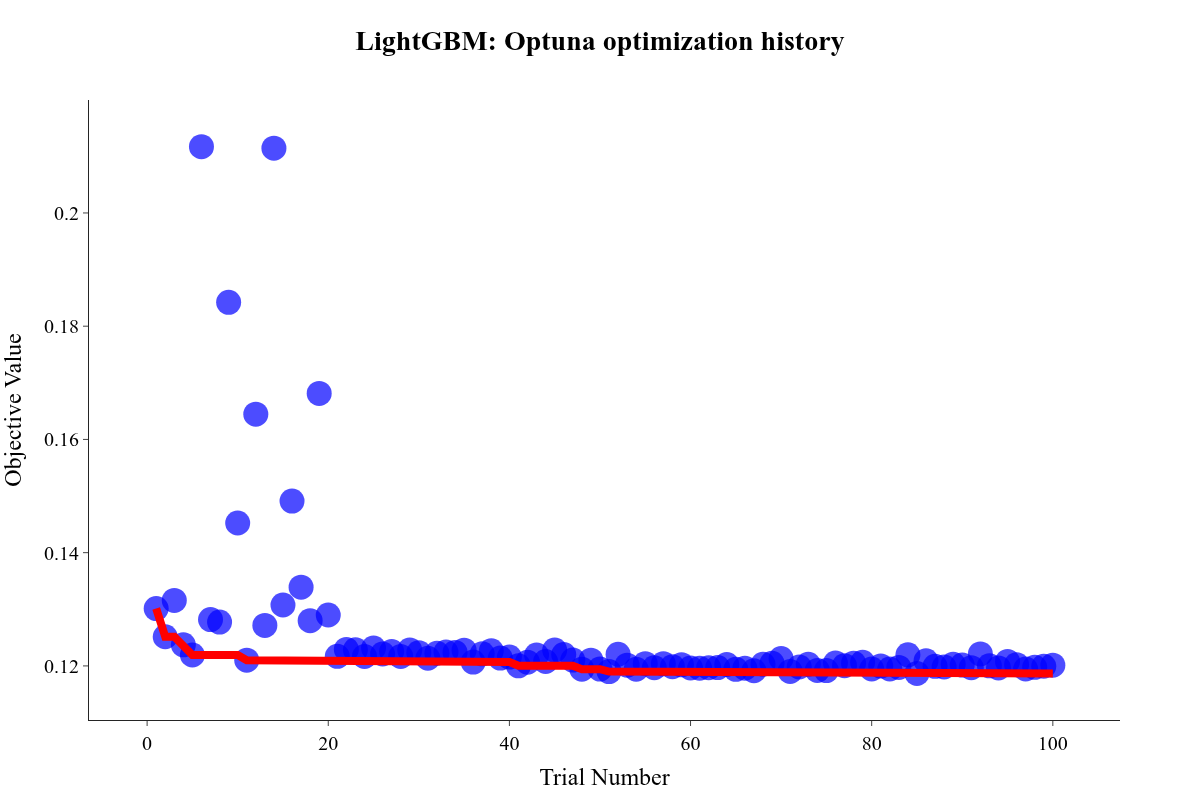

In [16]:
optuna_plots.plot_optuna_optimization_history( study, plot_title="LightGBM: Optuna optimization history", direction=METRICS[METRIC_NAME][2], )

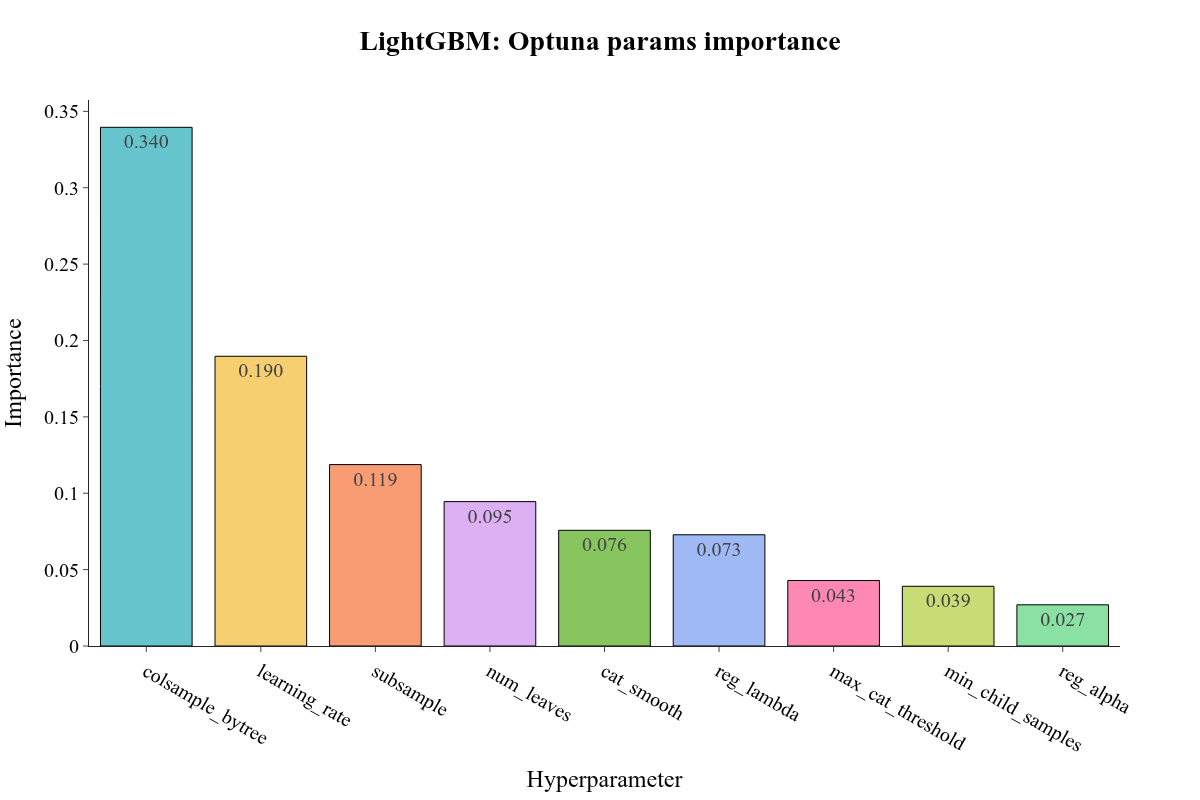

In [17]:
optuna_plots.plot_optuna_param_importance( study, plot_title="LightGBM: Optuna params importance" )

In [18]:
lgbm_model = LGBMRegressor(**lgbm_best_params)
train_scores, valid_scores, _ = cross_validation_trainer.fit( estimator=lgbm_model, X=train_data[independent_features], y=train_data[TARGET_FEATURE] )
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print( f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}" )

Train RMSE: 0.0300 +- 0.0003
Validation RMSE: 0.1156 +- 0.0064


## XGBoost

In [19]:
model = build_xgb_estimator(ctx)
params_grid = build_xgb_grid(ctx)

tuner = RandomSearchCV(cross_validator=cross_validation_trainer, n_trials=N_TRIALS, seed=SEED)
study = tuner.tune(model, train_data[independent_features], train_data[TARGET_FEATURE], params_grid)
xgb_best_params = tuner.best_params_
print(xgb_best_params)

🔍 Starting random search with 100 trials via cross-validation, target metric: RMSE (minimize).
🎛️  Search space: ['learning_rate', 'max_depth', 'min_child_weight', 'subsample', 'colsample_bytree', 'gamma', 'reg_lambda', 'reg_alpha', 'max_cat_threshold'] (9 tunable dimensions)
💾 Cached 5 preprocessed confirm folds (~0.00 GB), reused across every trial.
🌟 [confirm] Trial 1/100 | RMSE: 0.133424 | Best: 0.133424 (trial 1) | 0.99s | params: {'learning_rate': 0.3, 'max_depth': 4, 'min_child_weight': 1.0, 'subsample': 1.0, 'colsample_bytree': 1.0, 'gamma': 0.001, 'reg_lambda': 1.0, 'reg_alpha': 0.001, 'max_cat_threshold': 64}
🔁 [confirm] Trial 2/100 | RMSE: 0.140262 | Best: 0.133424 (trial 1) | 3.01s | params: {'learning_rate': 0.027243063237209188, 'max_depth': 4, 'min_child_weight': 1.3610287063285262, 'subsample': 0.5339501790956457, 'colsample_bytree': 0.8508898219999392, 'gamma': 0.4220210241659456, 'reg_lambda': 3.548816830746043, 'reg_alpha': 0.5066881321056522, 'max_cat_threshold': 16

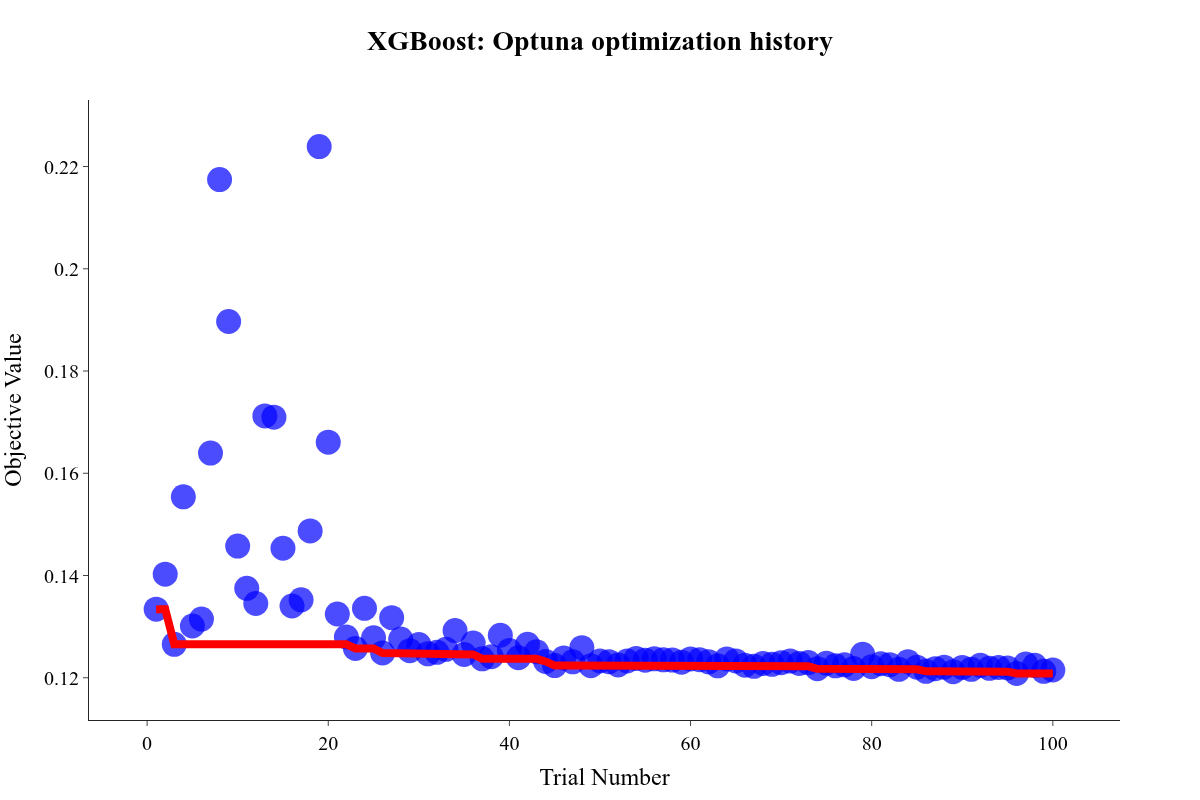

In [20]:
optuna_plots.plot_optuna_optimization_history( study, plot_title="XGBoost: Optuna optimization history", direction=METRICS[METRIC_NAME][2], )

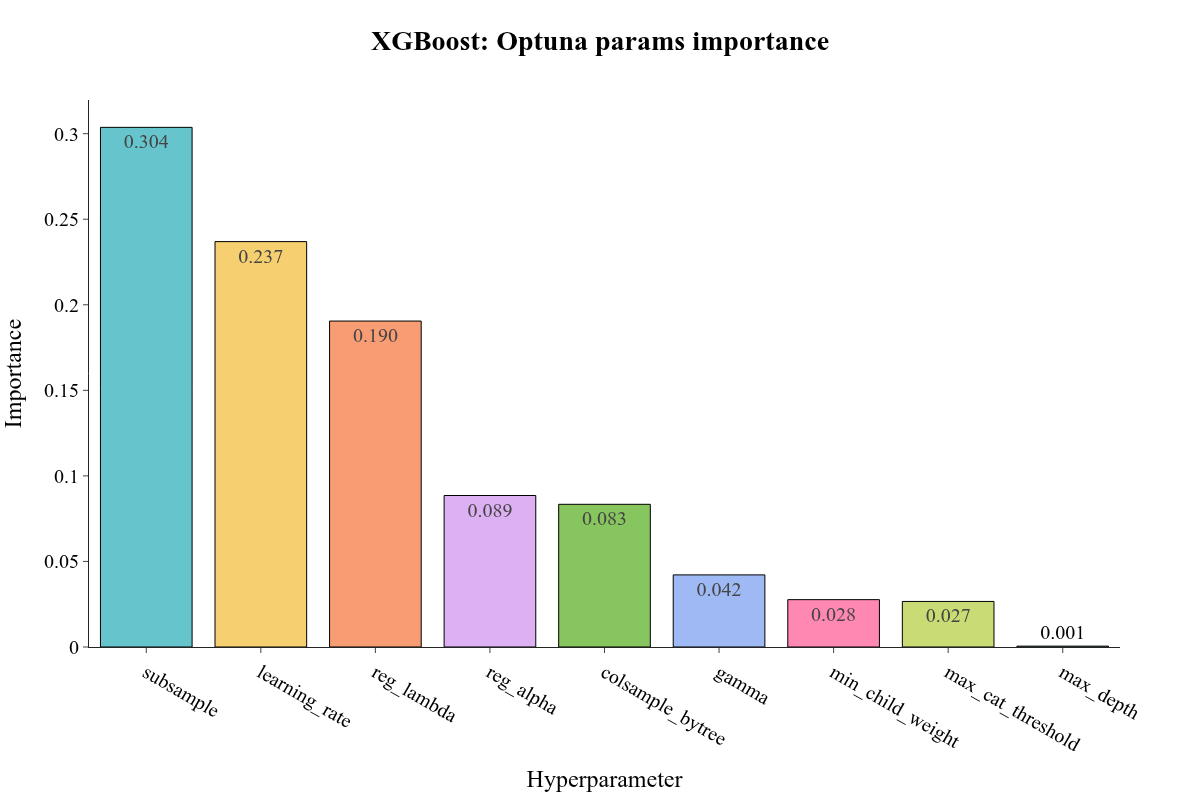

In [21]:
optuna_plots.plot_optuna_param_importance( study, plot_title="XGBoost: Optuna params importance" )

In [22]:
xgb_model = XGBRegressor(**xgb_best_params)
train_scores, valid_scores, _ = cross_validation_trainer.fit( estimator=xgb_model, X=train_data[independent_features], y=train_data[TARGET_FEATURE] )
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print( f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}" )

Train RMSE: 0.0329 +- 0.0003
Validation RMSE: 0.1196 +- 0.0050


## Catboost

In [23]:
model = build_catboost_estimator(ctx)
params_grid = build_catboost_grid(ctx)

tuner = RandomSearchCV(cross_validator=cross_validation_trainer, n_trials=N_TRIALS, seed=SEED)
study = tuner.tune(model, train_data[independent_features], train_data[TARGET_FEATURE], params_grid)
catboost_best_params = tuner.best_params_
print(catboost_best_params)

🔍 Starting random search with 100 trials via cross-validation, target metric: RMSE (minimize).
🎛️  Search space: ['learning_rate', 'depth', 'l2_leaf_reg', 'random_strength', 'subsample', 'one_hot_max_size'] (6 tunable dimensions)
💾 Cached 5 preprocessed confirm folds (~0.00 GB), reused across every trial.
🌟 [confirm] Trial 1/100 | RMSE: 0.119729 | Best: 0.119729 (trial 1) | 10.01s | params: {'learning_rate': 0.05, 'depth': 6, 'l2_leaf_reg': 3.0, 'random_strength': 1.0, 'subsample': 0.8, 'one_hot_max_size': 2}
🔁 [confirm] Trial 2/100 | RMSE: 0.119828 | Best: 0.119729 (trial 1) | 5.89s | params: {'learning_rate': 0.027243063237209188, 'depth': 5, 'l2_leaf_reg': 1.3793201474161445, 'random_strength': 0.01598457429671189, 'subsample': 0.8934927299999567, 'one_hot_max_size': 44}
🔁 [confirm] Trial 3/100 | RMSE: 0.121442 | Best: 0.119729 (trial 1) | 3.10s | params: {'learning_rate': 0.08743708405615638, 'depth': 5, 'l2_leaf_reg': 0.6149714387392291, 'random_strength': 0.11842429649211152, 'su

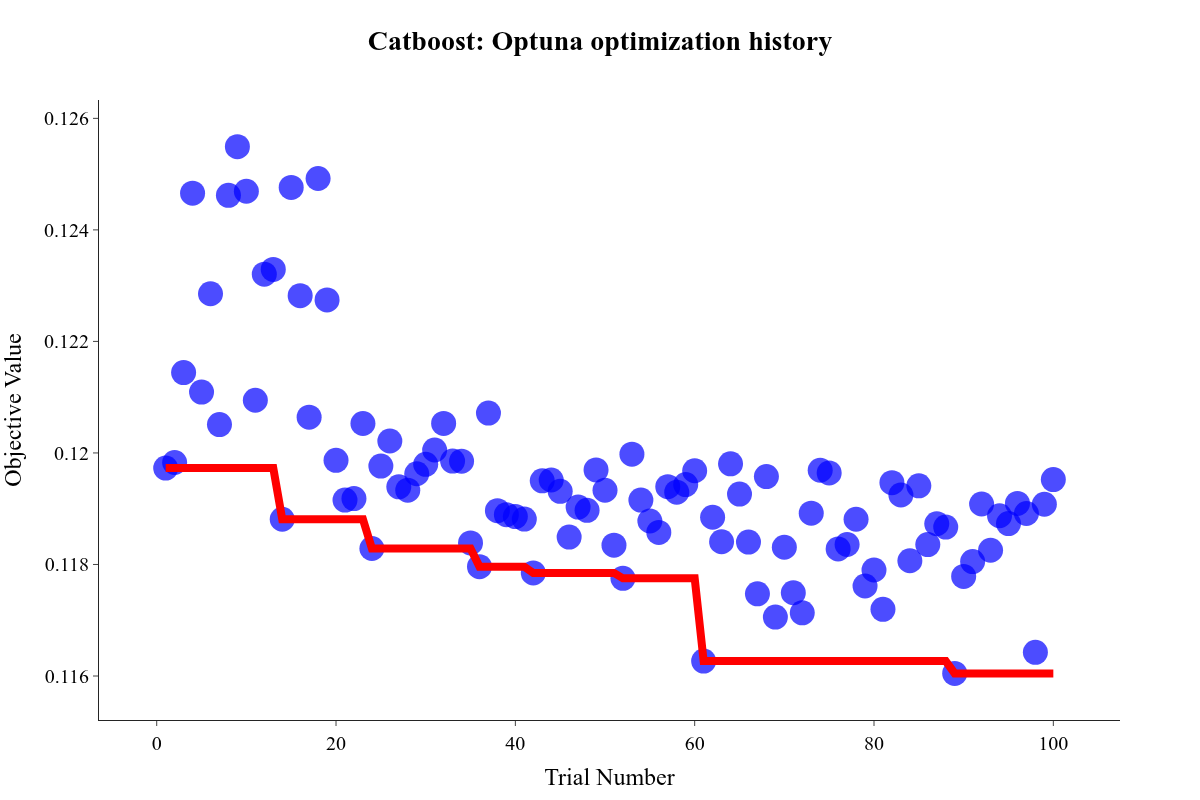

In [24]:
optuna_plots.plot_optuna_optimization_history( study, plot_title="Catboost: Optuna optimization history", direction=METRICS[METRIC_NAME][2], )

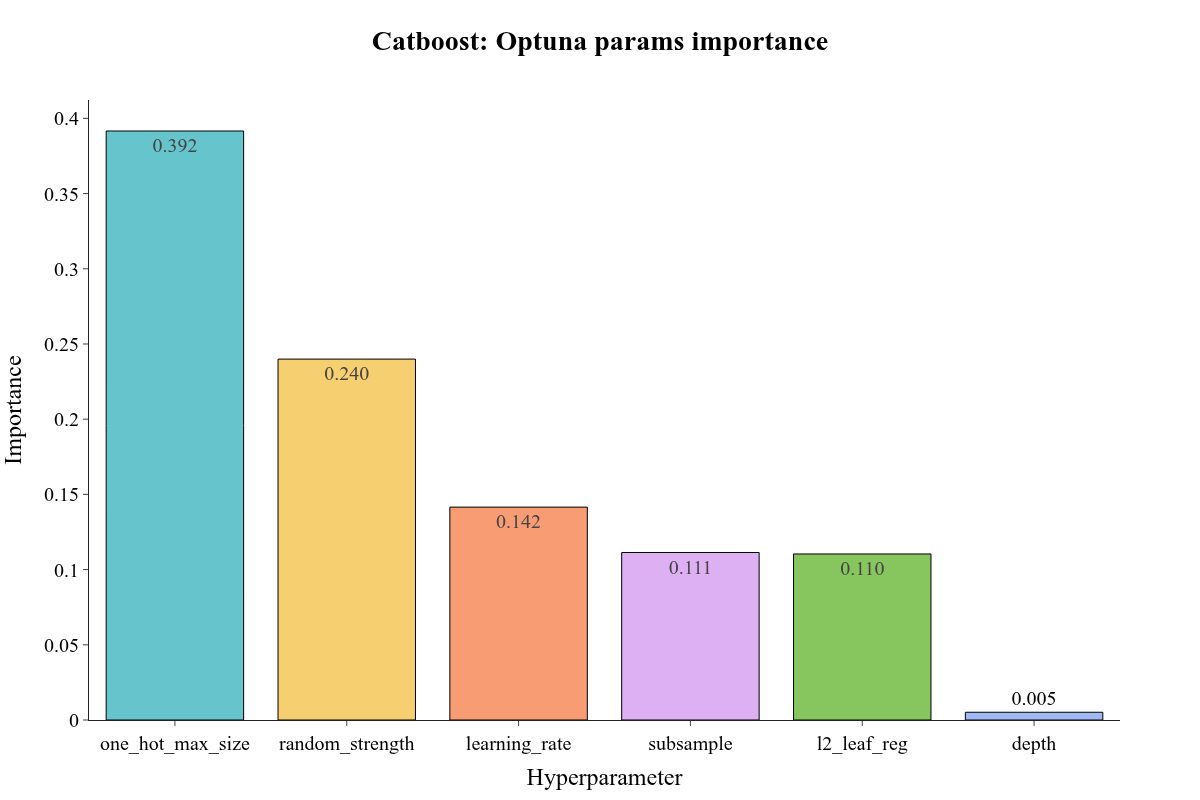

In [25]:
optuna_plots.plot_optuna_param_importance( study, plot_title="Catboost: Optuna params importance" )

In [26]:
catboost_model = CatBoostRegressor(**catboost_best_params)
train_scores, valid_scores, _ = cross_validation_trainer.fit( estimator=catboost_model, X=train_data[independent_features], y=train_data[TARGET_FEATURE] )
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print( f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}" )

Train RMSE: 0.0229 +- 0.0024
Validation RMSE: 0.1144 +- 0.0077


## Ensemble wights tuning

In [27]:
estimators = [lgbm_model, xgb_model, catboost_model]

In [28]:
ensemble_weights_tuner = EnsembleWeightTunerCV(
    estimators=estimators,
    cross_validator=cross_validation_trainer,
    n_trials=N_TRIALS * 5,
    seed=SEED,
    allow_negative_weights=False,
)
ensemble_weights_tuner.tune(
    train_data[independent_features], train_data[TARGET_FEATURE]
)
best_weights = ensemble_weights_tuner.best_weights
for i, estimator in enumerate(ensemble_weights_tuner.estimators):
    print(
        f"Estimator {i}: {estimator.__class__.__name__}, Weight: {best_weights[i]:.4f}"
    )

🔍 Starting ensemble weight search with 500 trials via cross-validation, target metric: RMSE (minimize).
🎛️  Blending 3 estimators: ['LGBMRegressor', 'XGBRegressor', 'CatBoostRegressor']
[EnsembleWeightTunerCV] LGBMRegressor OOF RMSE: 0.11555 +- 0.00635
[EnsembleWeightTunerCV] XGBRegressor OOF RMSE: 0.11961 +- 0.00495
[EnsembleWeightTunerCV] CatBoostRegressor OOF RMSE: 0.11436 +- 0.00771
🌟 Trial 1/500 | RMSE: 0.117305 | Best: 0.117305 (trial 1) | 0.00s | weights: [0.3333, 0.3333, 0.3333]
🔁 Trial 2/500 | RMSE: 0.118729 | Best: 0.117305 (trial 1) | 0.00s | weights: [1.0, 0.0, 0.0]
🔁 Trial 3/500 | RMSE: 0.122084 | Best: 0.117305 (trial 1) | 0.00s | weights: [0.0, 1.0, 0.0]
🔁 Trial 4/500 | RMSE: 0.118216 | Best: 0.117305 (trial 1) | 0.00s | weights: [0.0, 0.0, 1.0]
🔁 Trial 5/500 | RMSE: 0.118184 | Best: 0.117305 (trial 1) | 0.00s | weights: [0.2898, 0.5218, 0.1884]
🔁 Trial 6/500 | RMSE: 0.118068 | Best: 0.117305 (trial 1) | 0.00s | weights: [0.0449, 0.5208, 0.4343]
🔁 Trial 7/500 | RMSE: 0.1

In [29]:
ensemble_model = EnsembleModel( estimators=ensemble_weights_tuner.estimators, problem_type=PROBLEM_TYPE, weights=ensemble_weights_tuner.best_weights, )
train_scores, valid_scores, _ = cross_validation_trainer.fit( estimator=ensemble_model, X=train_data[independent_features], y=train_data[TARGET_FEATURE], )
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print( f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}" )

Train RMSE: 0.0256 +- 0.0013
Validation RMSE: 0.1135 +- 0.0068


In [30]:
final_model = ensemble_model

# Evaluation

In [31]:
train_data_temp, test_data_temp = train_test_split(train_data, test_size=0.1, random_state=SEED, shuffle=True)

In [32]:
X_train_temp = train_data_temp.drop(columns=[TARGET_FEATURE]).copy()
y_train_temp = train_data_temp[TARGET_FEATURE]
X_test_temp = test_data_temp.drop(columns=[TARGET_FEATURE], errors="ignore").copy()
y_test_temp = test_data_temp[TARGET_FEATURE] if TARGET_FEATURE in test_data_temp.columns else None

X_train_temp_transformed = preprocessing_pipeline.fit_transform(X=X_train_temp, y=y_train_temp)
X_test_temp_transformed = preprocessing_pipeline.transform(X=X_test_temp)

final_model.fit( X_train_temp_transformed, y_train_temp, eval_set=[(X_test_temp_transformed, y_test_temp)],)

y_train_pred = final_model.predict(X_train_temp_transformed)
y_test_pred = final_model.predict(X_test_temp_transformed)

In [33]:
regression_results(y_train_true=y_train_temp, y_train_pred=y_train_pred, y_test_true=y_test_temp, y_test_pred=y_test_pred)

,MAE,MedAE,MSE,RMSE,MAPE,R²,Explained Var
Train,0.0205,0.0165,0.0007,0.0267,0.17%,0.9955,0.9955
Test,0.0873,0.0633,0.0140,0.1184,0.73%,0.9148,0.9148


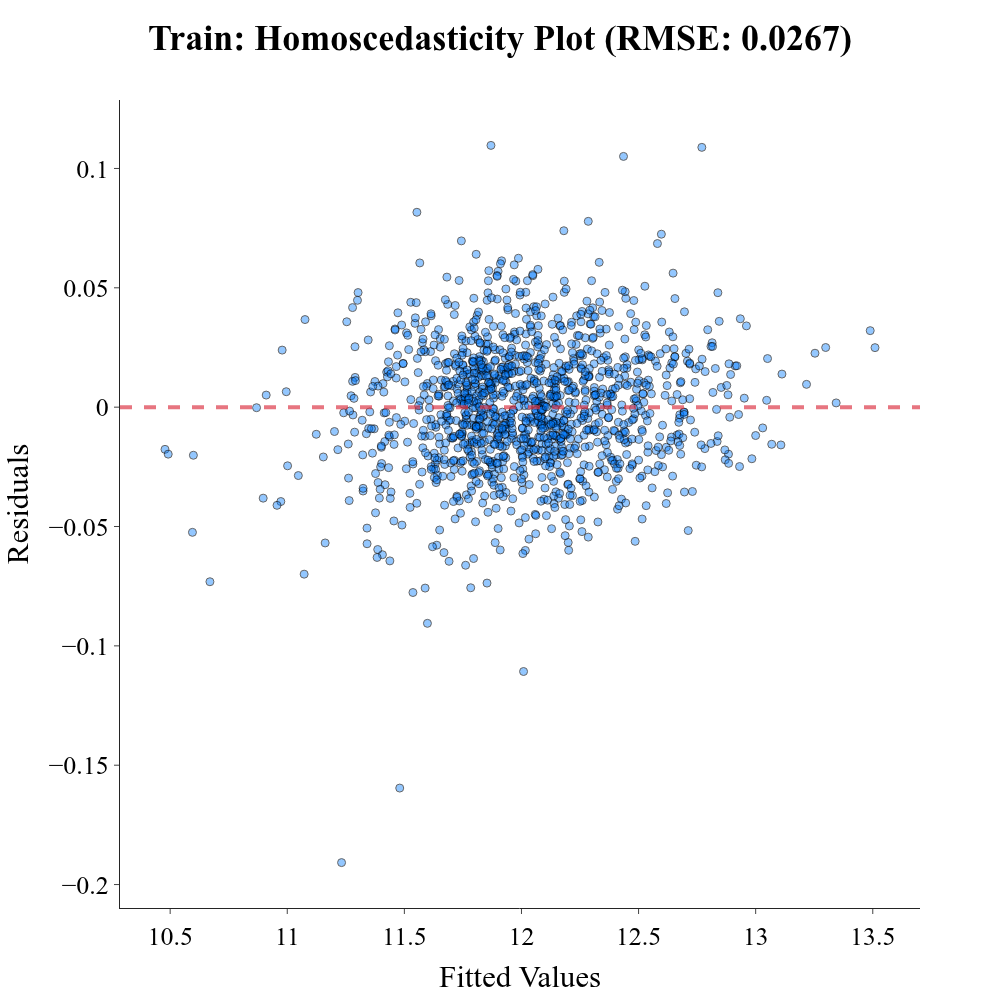

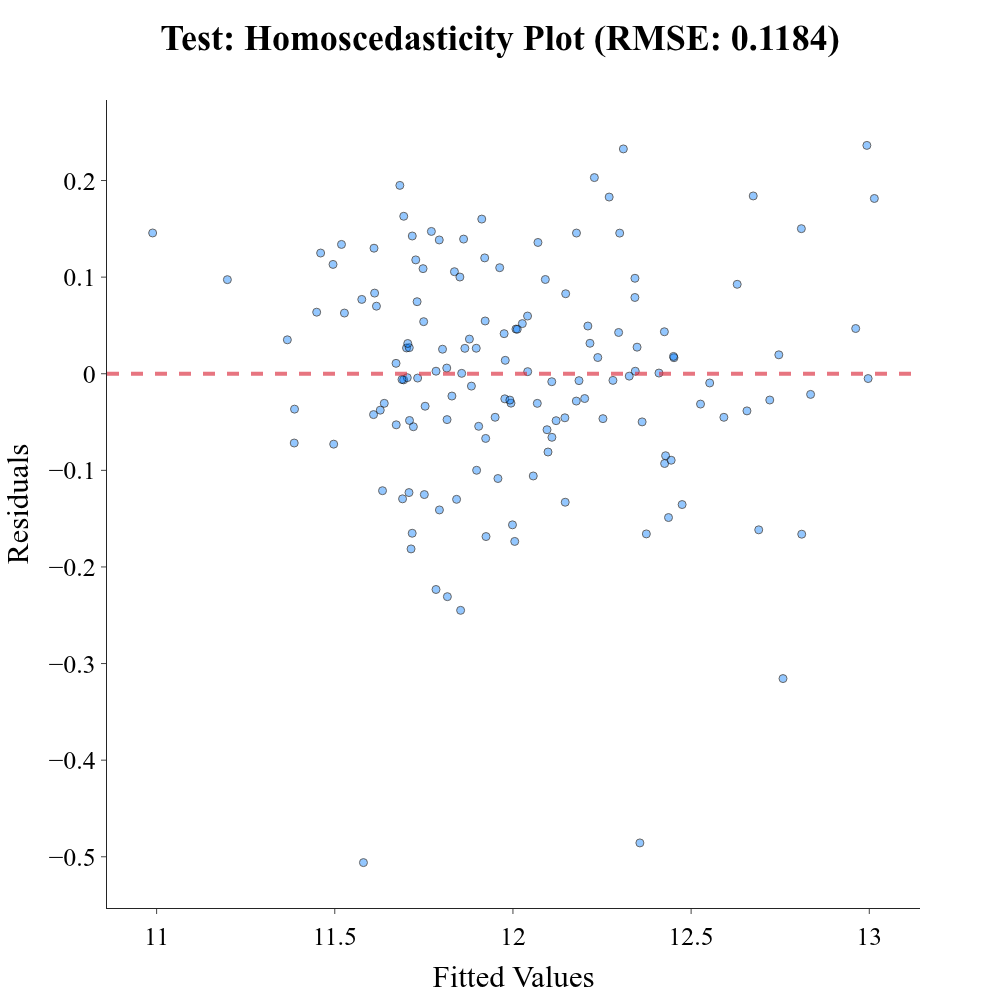

In [34]:
regression_plots.homoscedacity_plot(y_true=y_train_temp, y_pred=y_train_pred, plot_title="Train: Homoscedasticity Plot", metric_name="RMSE")
regression_plots.homoscedacity_plot(y_true=y_test_temp, y_pred=y_test_pred, plot_title="Test: Homoscedasticity Plot", metric_name="RMSE")

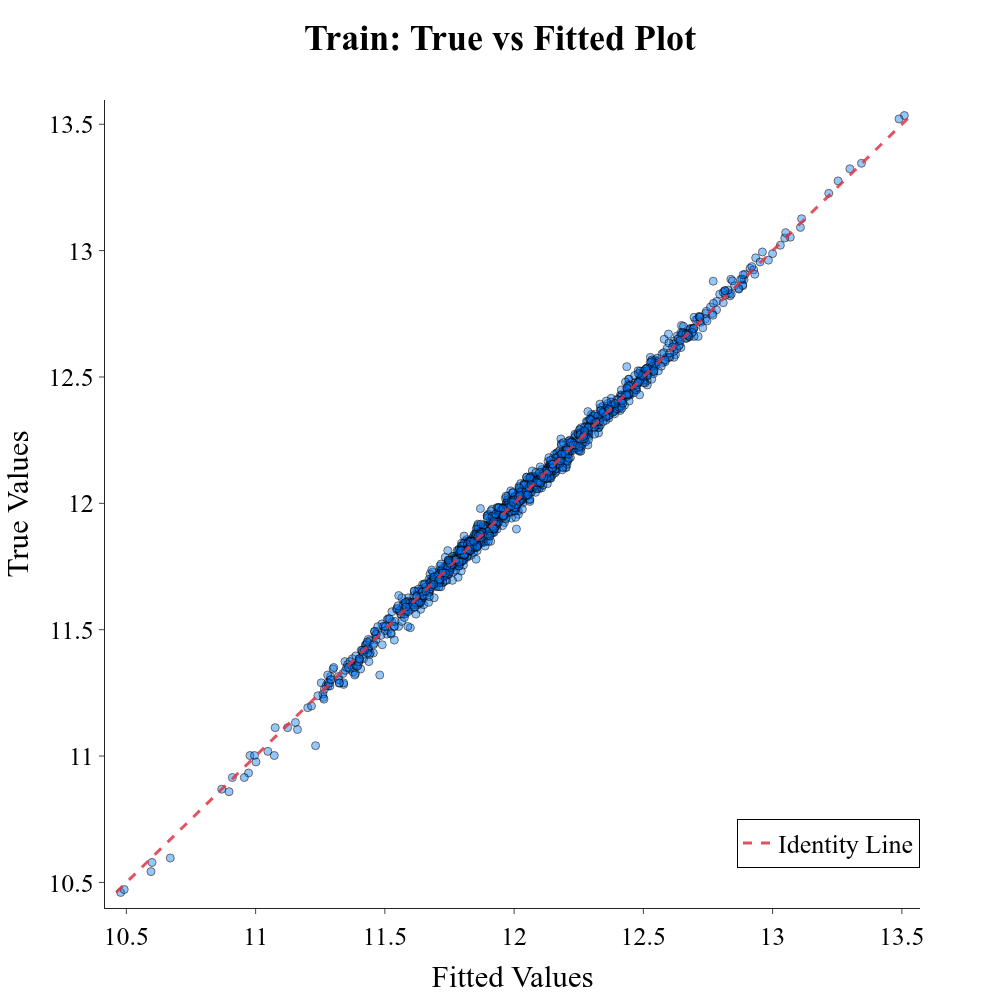

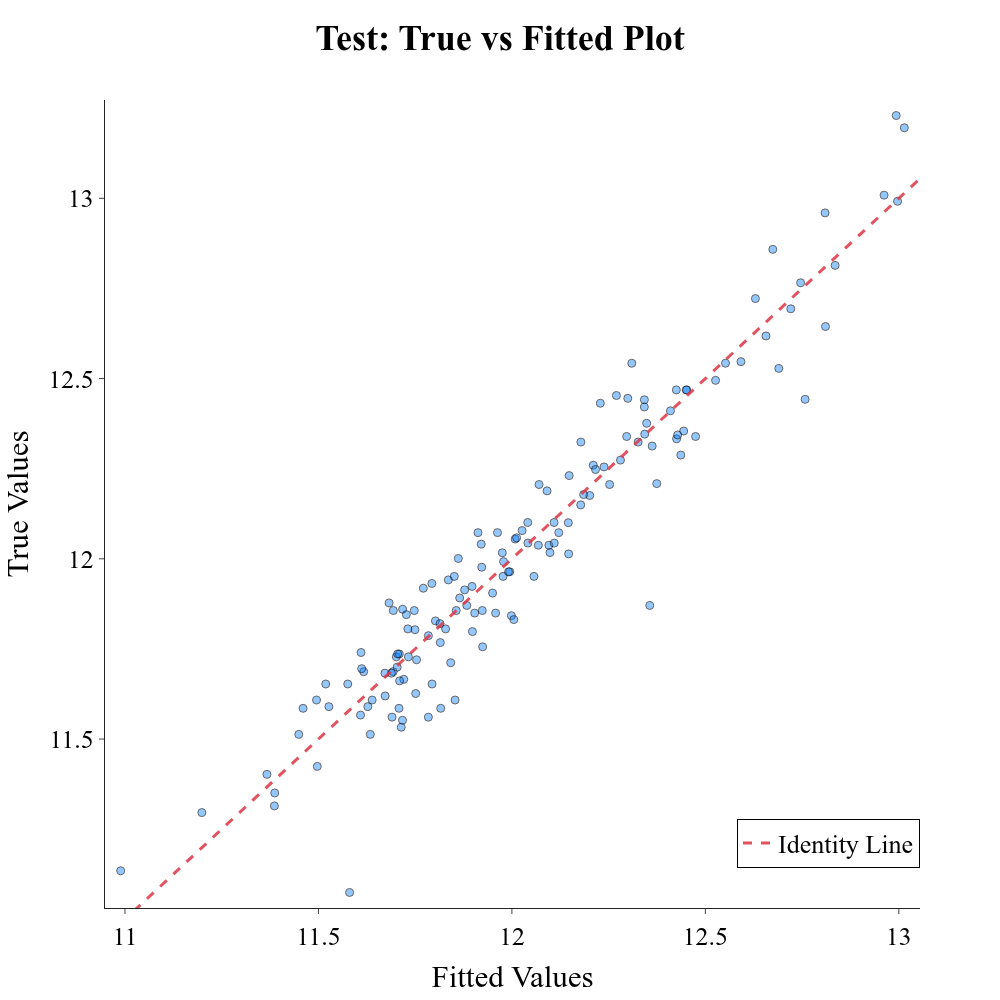

In [35]:
regression_plots.true_vs_fitted_plot(y_true=y_train_temp, y_pred=y_train_pred, plot_title="Train: True vs Fitted Plot", metric_name="RMSE")
regression_plots.true_vs_fitted_plot(y_true=y_test_temp, y_pred=y_test_pred, plot_title="Test: True vs Fitted Plot", metric_name="RMSE")

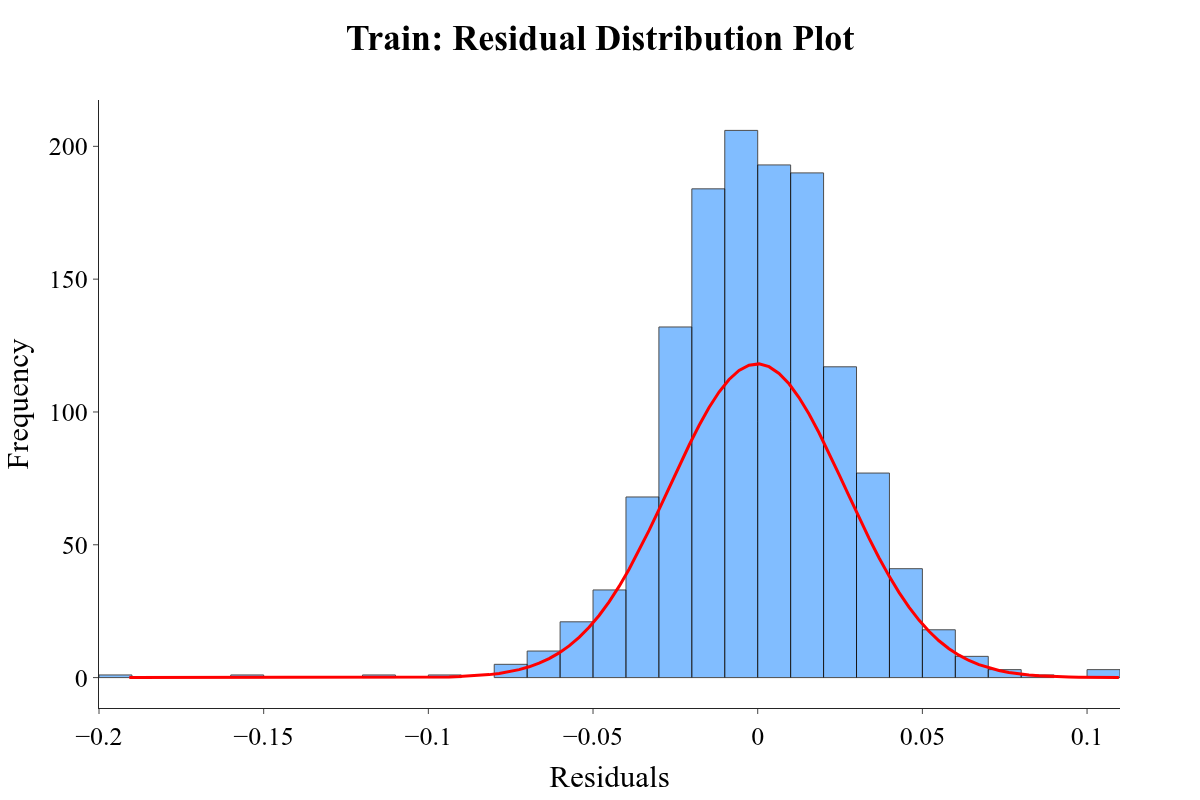

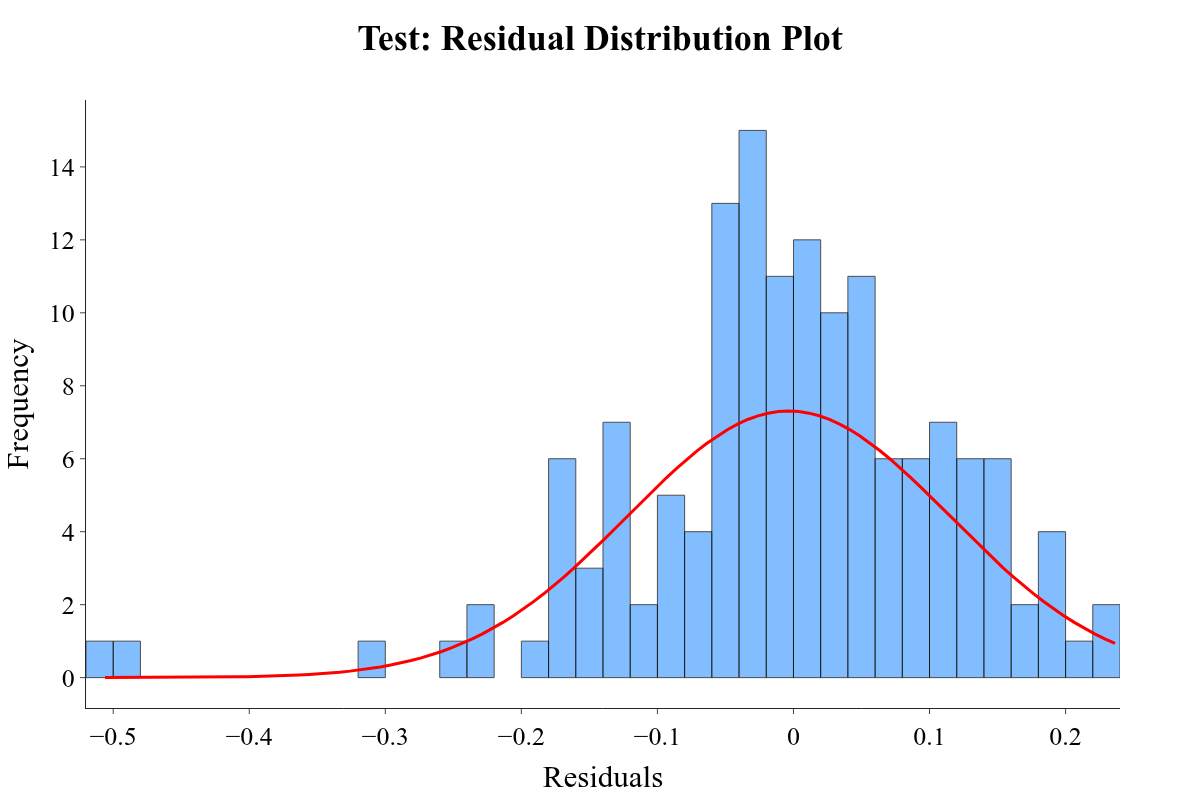

In [36]:
regression_plots.residual_distribution_plot(y_true=y_train_temp, y_pred=y_train_pred, plot_title="Train: Residual Distribution Plot", metric_name="RMSE")
regression_plots.residual_distribution_plot(y_true=y_test_temp, y_pred=y_test_pred, plot_title="Test: Residual Distribution Plot", metric_name="RMSE")

## Feature importance

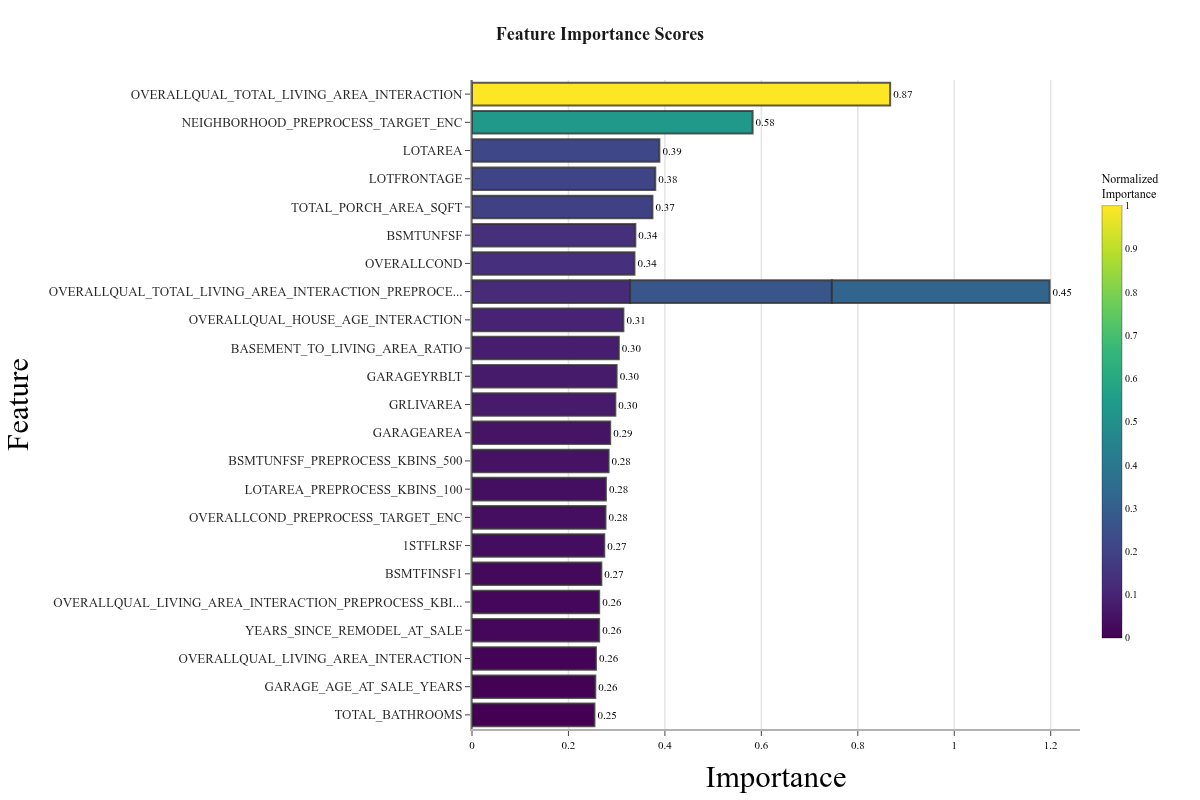

In [37]:
feature_importance_df = pd.DataFrame(
    {
        "feature": X_train_temp_transformed.columns,
        "importance": final_model.feature_importances_,
    }
).sort_values(by="importance", ascending=False)
other_plots.feature_importance_plot(feature_importance_df.set_index("feature")["importance"].to_dict(), plot_title="Feature Importance Scores", top_n=25)

### SHAP values

In [38]:
shap_values = compute_shap_values(final_model, X_test_temp_transformed)

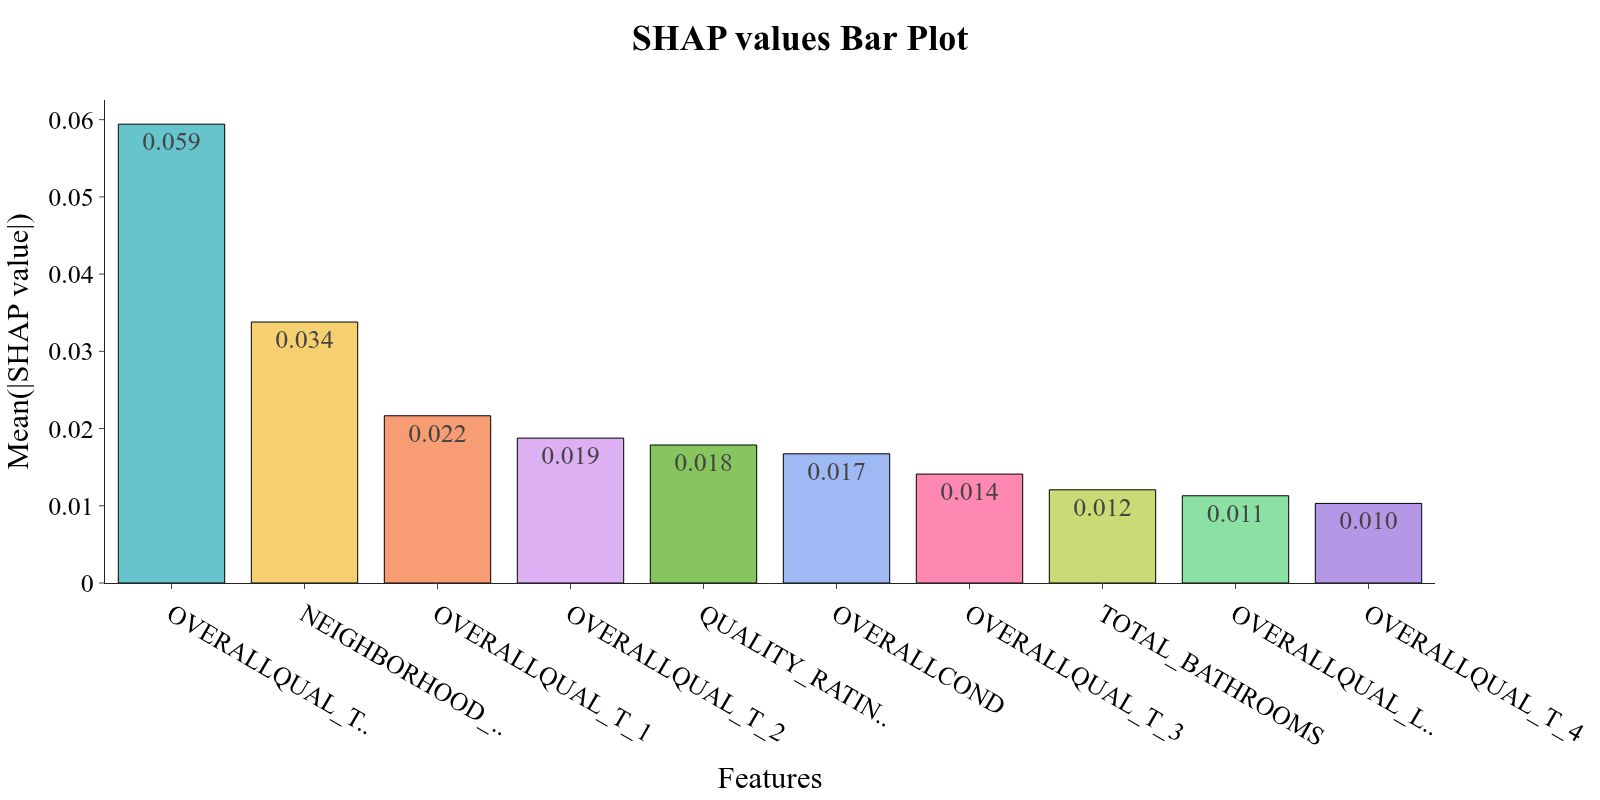

In [39]:
shap_plots.plot_shap_bar(shap_values=shap_values, top_n=10, plot_title="SHAP values Bar Plot")

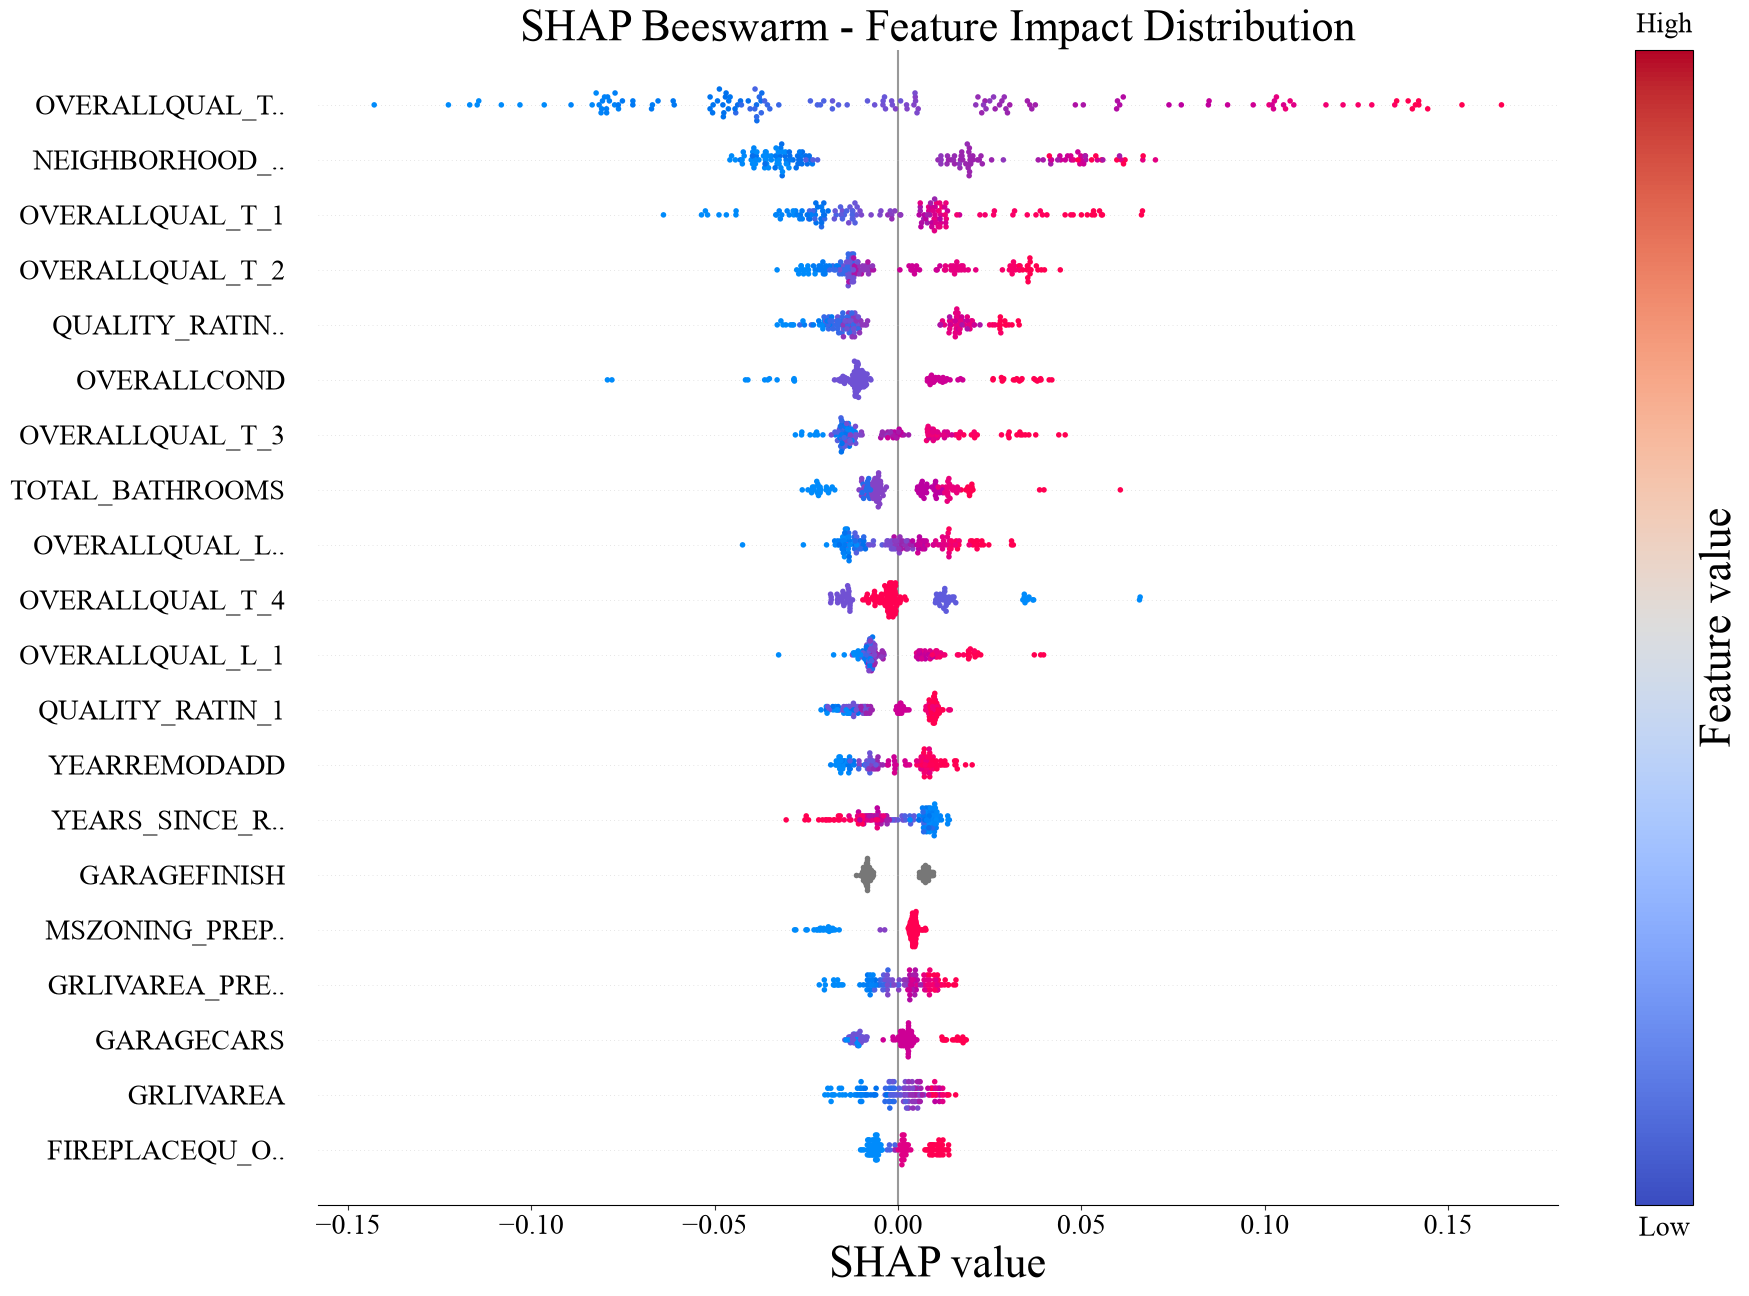

In [40]:
%matplotlib inline
shap_plots.plot_custom_shap_beeswarm(shap_values=shap_values, top_n=20, plot_title="SHAP Beeswarm - Feature Impact Distribution")

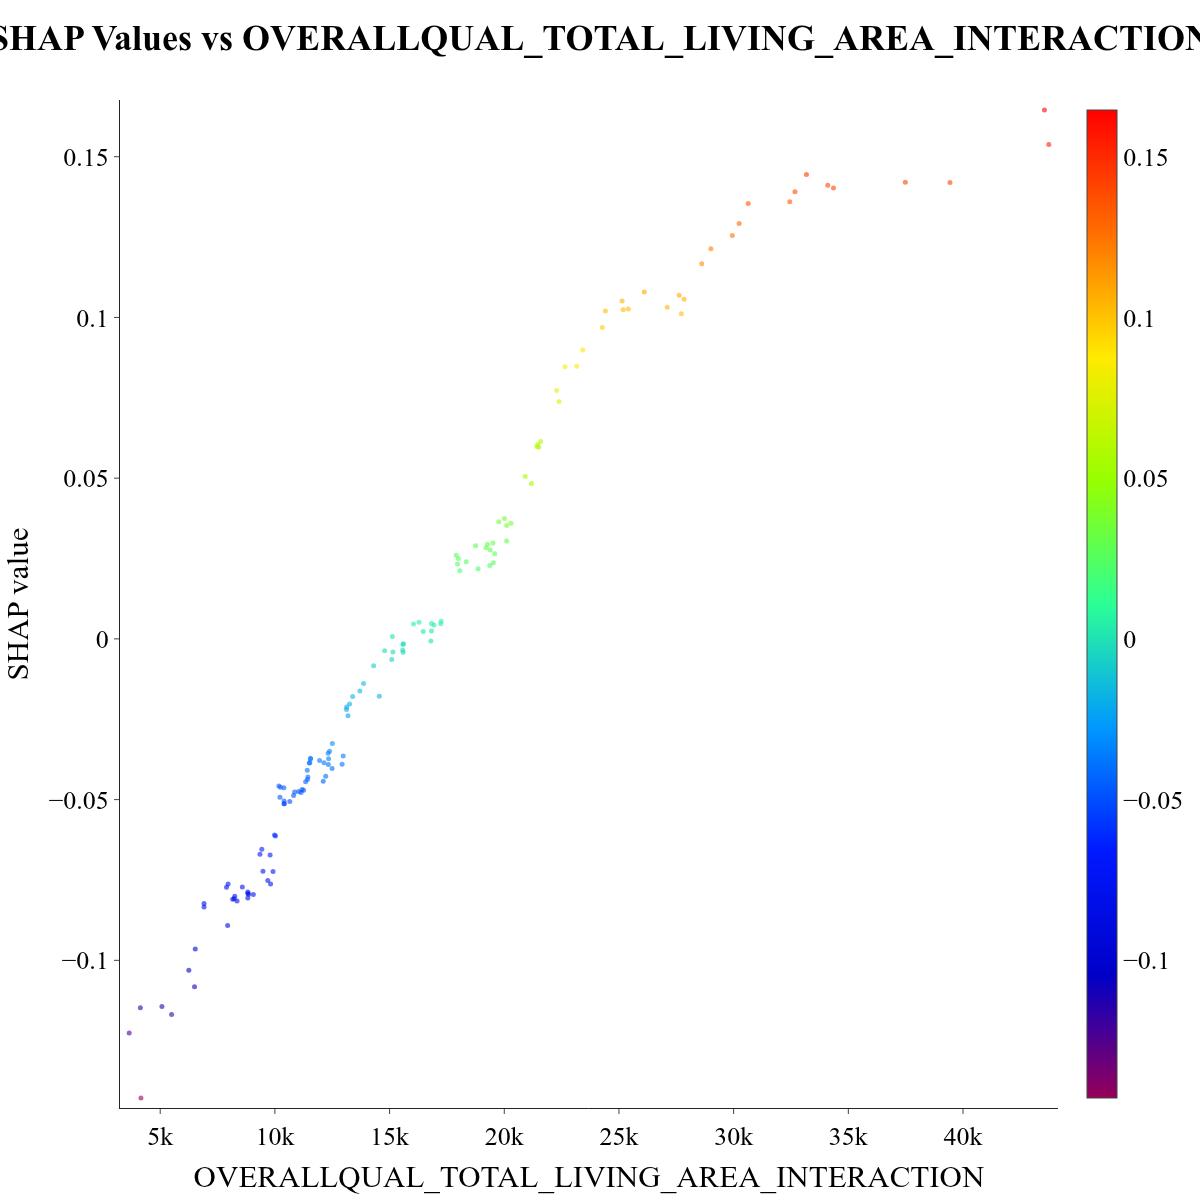

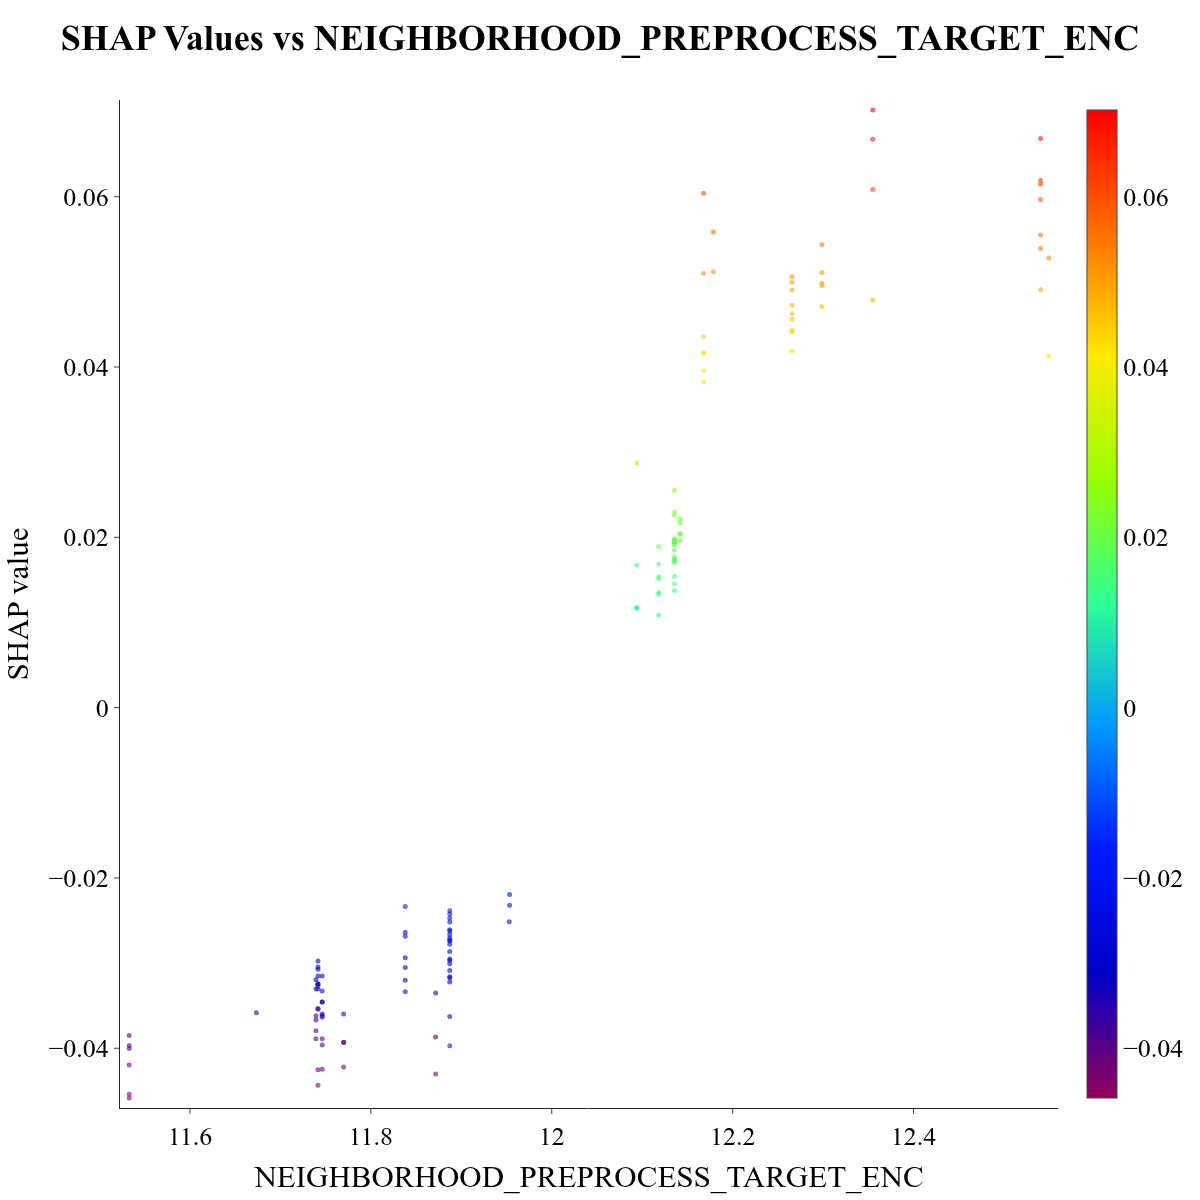

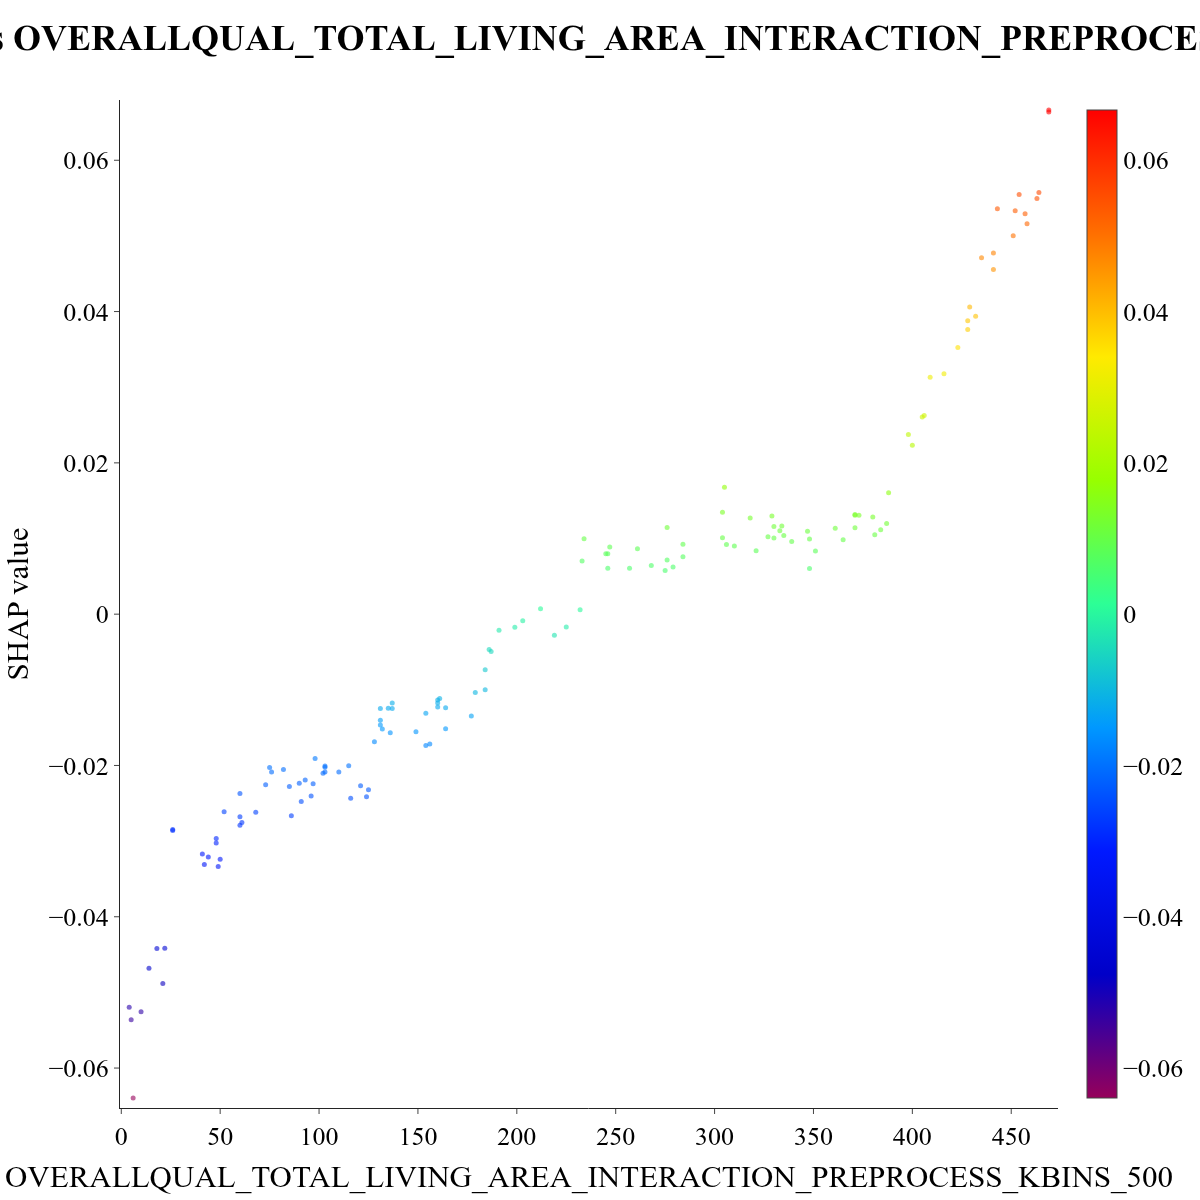

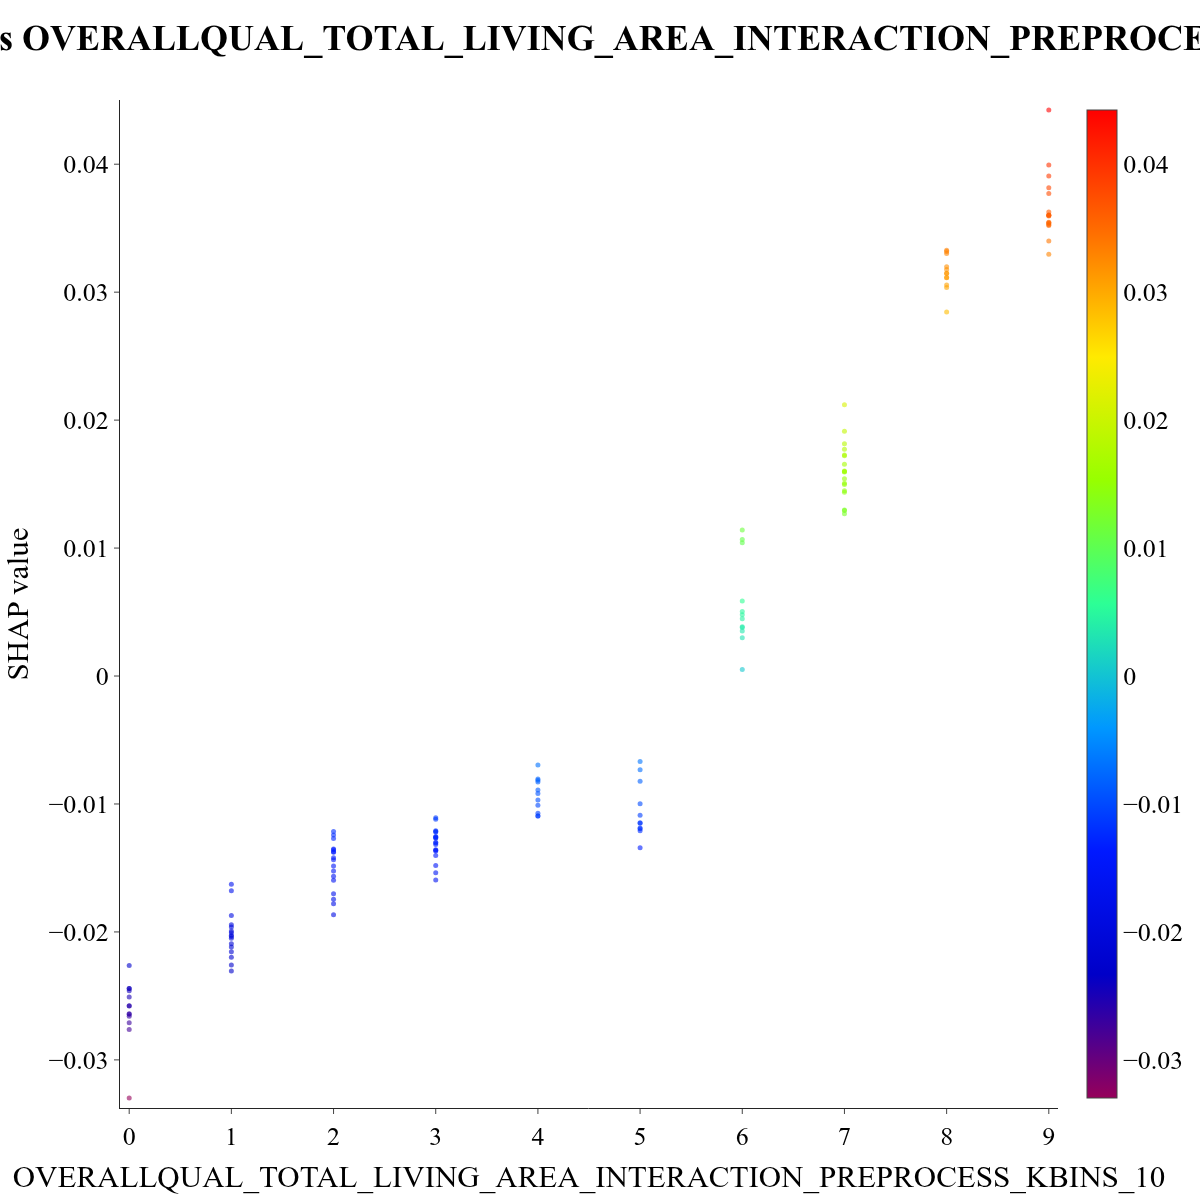

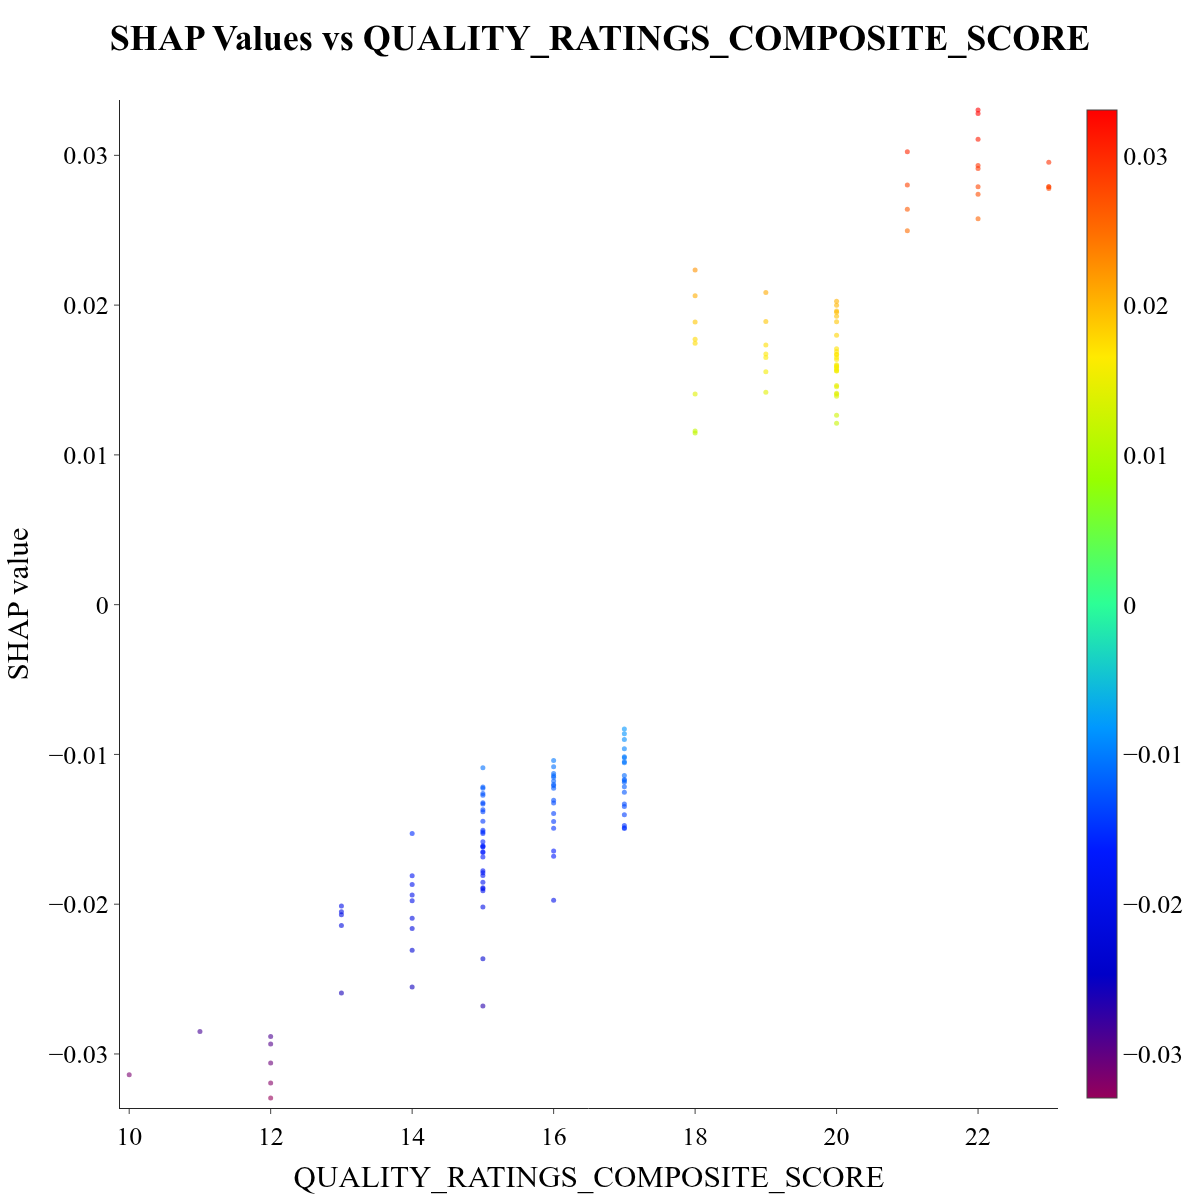

In [41]:
_, top_features, top_shap_mean_values = shap_plots._compute_shap_importance(
    shap_values, top_n=5
)
for feature in top_features:
    scatter = shap_values[:, feature]
    if X_test_transformed[feature].dtype.name == 'category':
        shap_plots.plot_shap_categorical_box(scatter, feature)
    else:
        shap_plots.plot_shap_numerical_scatter(scatter, feature)

# Final Submission

In [42]:
def submit_to_kaggle(predictions: np.ndarray, submission_data: pd.DataFrame, competition_name: str, message: str = "Submission") -> None:
    """
    Submits predictions to a Kaggle competition.
    
    Args:
        predictions (np.ndarray): Array of predictions to submit.
        submission_data (pd.DataFrame): DataFrame containing the submission format.
        competition_name (str): Name of the Kaggle competition.
        message (str): Submission message.
    """
    api = KaggleApi()
    api.authenticate()
    submission_data[submission_data.columns[1]] = predictions
    submission_data.to_csv("submission.csv", index=False)
    api.competition_submit(file_name="submission.csv", message=message, competition=competition_name)
    display(submission_data.head())

submission_data = pd.read_csv("data/sample_submission.csv")

In [43]:
def inverse_transform_predictions(predictions: np.ndarray) -> np.ndarray:
    """
    Inverse transforms predictions that were log-transformed using np.log1p.
    
    Args:
        predictions (np.ndarray): Array of log-transformed predictions.
    
    Returns:
        np.ndarray: Array of predictions in the original scale.
    """
    return np.expm1(predictions)

## Submission (traditional approach)

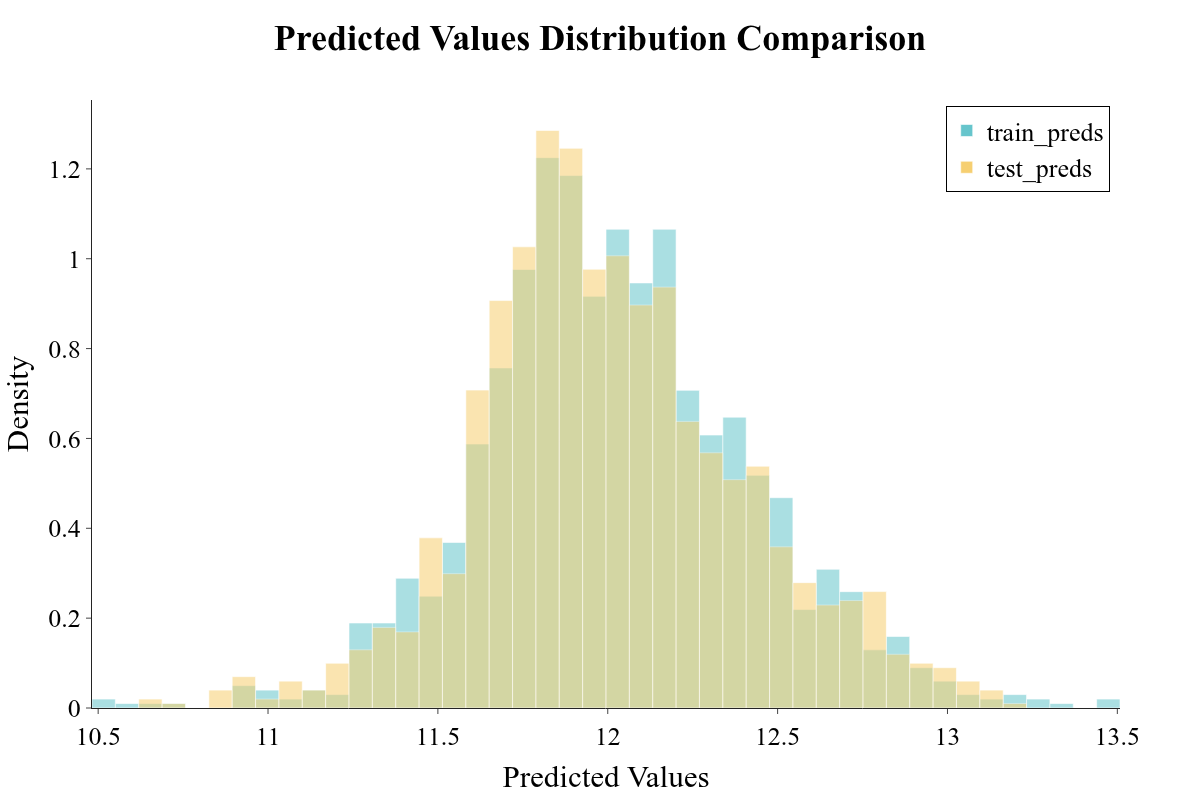

100%|██████████| 33.7k/33.7k [00:00<00:00, 77.4kB/s]


,Id,SalePrice
0,1461,121670.259710
1,1462,161118.832921
2,1463,176123.895331
3,1464,197474.317968
4,1465,179646.963853


In [44]:
def disable_early_stopping(estimator: object) -> object:
    """
    Disable early stopping for supported estimators.

    Args:
        estimator (object): The estimator to modify.

    Returns:
        object: The estimator with early stopping disabled.
    """
    if hasattr(estimator, "early_stopping_round"):
        estimator.set_params(early_stopping_round=None)
    elif hasattr(estimator, "early_stopping"):
        if "LGBM" in estimator.__class__.__name__:
            estimator.set_params(early_stopping=None)
        elif "HistGradientBoosting" in estimator.__class__.__name__:
            estimator.set_params(early_stopping=False)
    elif hasattr(estimator, "early_stopping_rounds"):
        estimator.set_params(early_stopping_rounds=None)
    return estimator

X_train = train_data.drop(columns=[TARGET_FEATURE]).copy()
y_train = train_data[TARGET_FEATURE]
X_test = test_data.drop(columns=[TARGET_FEATURE], errors="ignore").copy()

X_train_transformed = preprocessing_pipeline.fit_transform(X=X_train, y=y_train)
X_test_transformed = preprocessing_pipeline.transform(X=X_test)

final_model_no_early_stopping = deepcopy(final_model)
if hasattr(final_model_no_early_stopping, "estimators"):
    final_model_no_early_stopping.estimators = [ disable_early_stopping(est) for est in final_model_no_early_stopping.estimators ]
else:
    final_model_no_early_stopping = disable_early_stopping( final_model_no_early_stopping )

final_model_no_early_stopping.fit( X_train_transformed, y_train)
train_preds = final_model_no_early_stopping.predict( X_train_transformed )
test_preds = final_model_no_early_stopping.predict( X_test_transformed )
continuous_plots.compare_distributions_plot(
    data={
        "train_preds": train_preds,
        "test_preds": test_preds
    },
    plot_title="Predicted Values Distribution Comparison",
    xaxis_title="Predicted Values",
    yaxis_title="Density"
)

submit_to_kaggle( predictions=inverse_transform_predictions(test_preds), submission_data=submission_data, competition_name=COMPETITION_NAME, message="Final Submission (traditional approach)", )

## Submission (validation set approach)

In [45]:
train_data_temp, test_data_temp = train_test_split(train_data, test_size=0.1, random_state=SEED, shuffle=True)
X_train_temp = train_data_temp.drop(columns=[TARGET_FEATURE]).copy()
y_train_temp = train_data_temp[TARGET_FEATURE]
X_test_temp = test_data_temp.drop(columns=[TARGET_FEATURE], errors="ignore").copy()
y_test_temp = test_data_temp[TARGET_FEATURE]

X_train_temp_transformed = preprocessing_pipeline.fit_transform(X=X_train_temp, y=y_train_temp)
X_test_temp_transformed = preprocessing_pipeline.transform(X=X_test_temp)

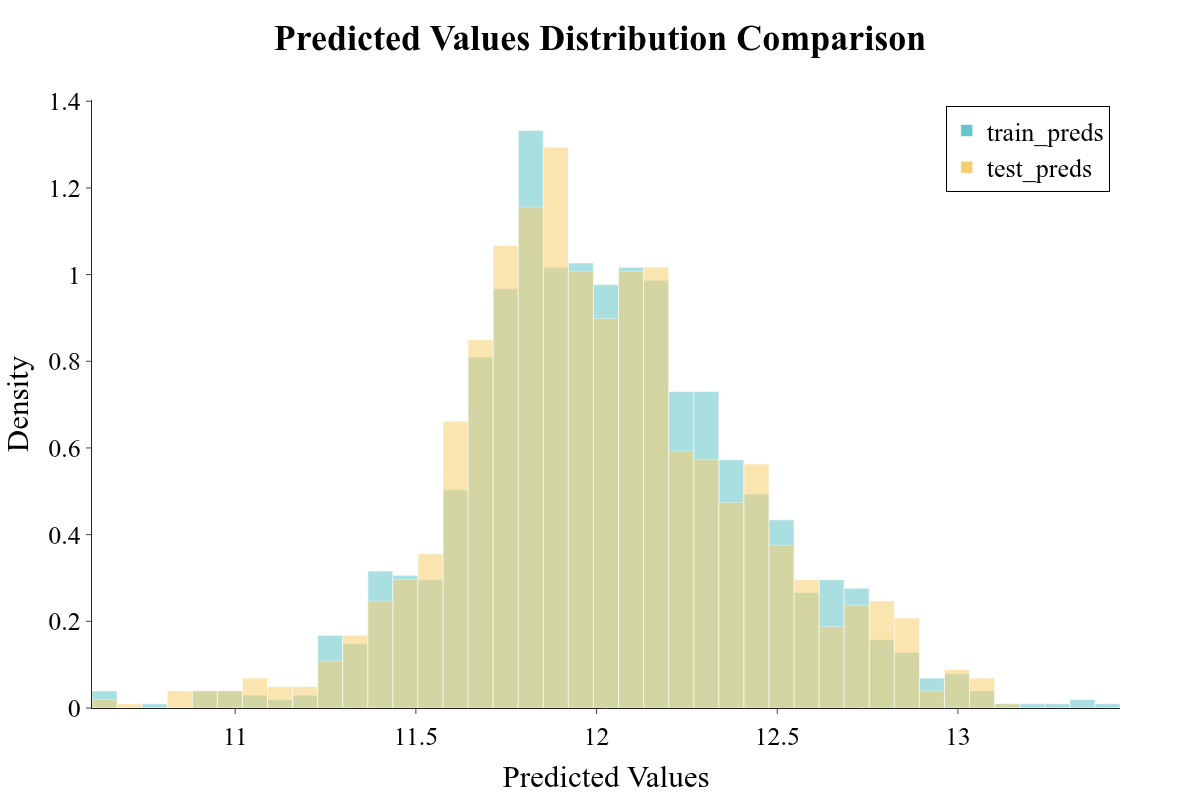

100%|██████████| 33.7k/33.7k [00:00<00:00, 84.8kB/s]


,Id,SalePrice
0,1461,118696.403562
1,1462,164706.028841
2,1463,173874.692219
3,1464,198011.443387
4,1465,178239.706509


In [46]:
final_model.fit( X_train_temp_transformed, y_train_temp, eval_set=[(X_test_temp_transformed, y_test_temp)])
train_preds = final_model.predict( X_train_transformed )
test_preds = final_model.predict( X_test_transformed )

continuous_plots.compare_distributions_plot(
    data={
        "train_preds": train_preds,
        "test_preds": test_preds
    },
    plot_title="Predicted Values Distribution Comparison",
    xaxis_title="Predicted Values",
    yaxis_title="Density"
)

submit_to_kaggle( predictions=inverse_transform_predictions(test_preds), submission_data=submission_data, competition_name=COMPETITION_NAME, message="Final Submission (with early stopping)", )

## Submission (OOF approach)

Train RMSE: 0.0256 +- 0.0013
Validation RMSE: 0.1135 +- 0.0068


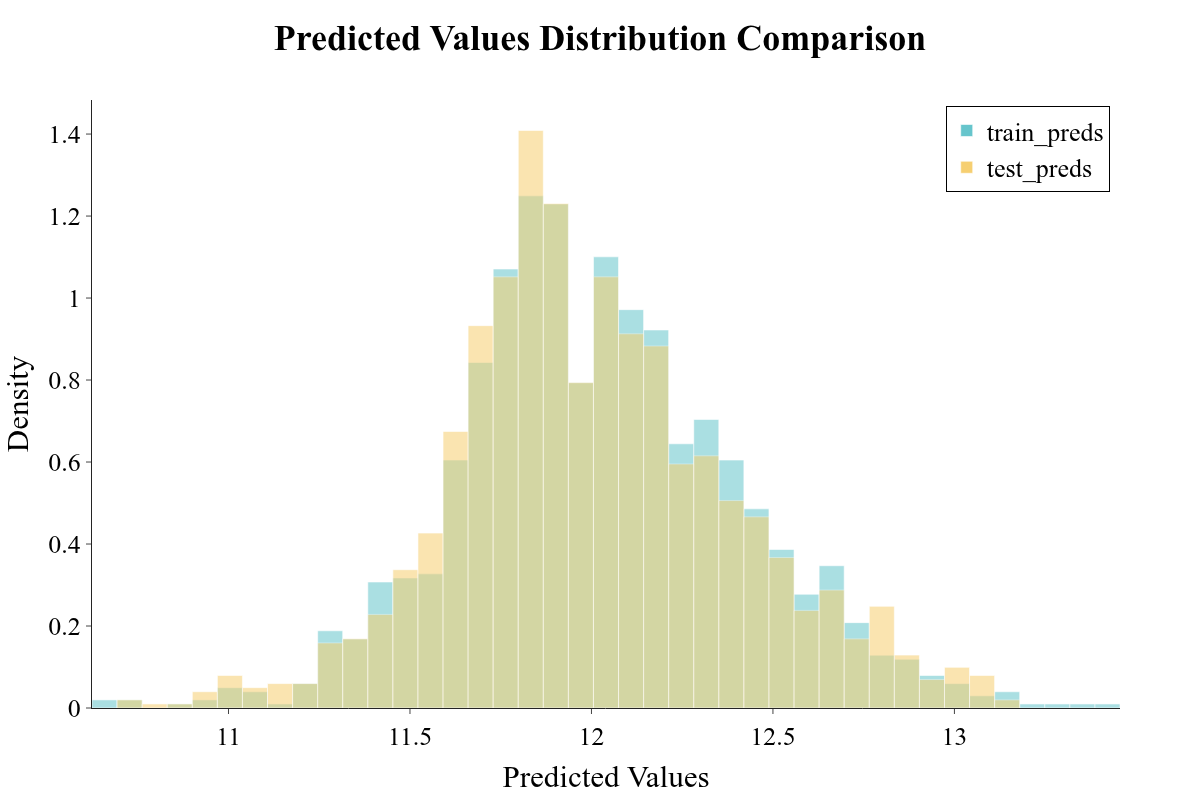

100%|██████████| 33.7k/33.7k [00:00<00:00, 80.3kB/s]


,Id,SalePrice
0,1461,119328.698840
1,1462,162794.185413
2,1463,175942.717736
3,1464,196633.536461
4,1465,182018.279331


In [47]:
cross_validation_trainer = CrossValidationTrainer(
    metric_name=METRIC_NAME,
    problem_type=PROBLEM_TYPE,
    preprocessing_pipeline=preprocessing_pipeline,
    cv=CV,
    verbose=False,
)

train_scores, valid_scores, avg_test_pred = cross_validation_trainer.fit( estimator=deepcopy(final_model), X=train_data[independent_features], y=train_data[TARGET_FEATURE], X_test=test_data[independent_features], )
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print( f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}" )

train_preds = cross_validation_trainer.predict(X=train_data[independent_features])
test_preds = avg_test_pred
continuous_plots.compare_distributions_plot(
    data={
        "train_preds": train_preds,
        "test_preds": test_preds
    },
    plot_title="Predicted Values Distribution Comparison",
    xaxis_title="Predicted Values",
    yaxis_title="Density"
)

submit_to_kaggle(predictions=inverse_transform_predictions(test_preds), submission_data=submission_data, competition_name=COMPETITION_NAME, message="Final Submission (OOF predictions)", )